In [2]:
"""
Zero-Shot Clustering Algorithm Comparison for Bengali Coreference Resolution
Author: Zenith Biswas
Date: December 2025

Systematic evaluation of 10 pre-trained models on BenCoref dataset (122 documents)
comparing 4 clustering algorithms with multiple thresholds and embedding strategies.

GOAL: Identify optimal zero-shot configuration for each model, then select 
4 models (one per category) for fine-tuning experiments.
"""

# Suppress warnings
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"
import warnings
warnings.filterwarnings("ignore")

# Core imports
import json
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Dict, List, Tuple, Optional
from dataclasses import dataclass, field
from collections import defaultdict
from datetime import datetime
import time
import gc

# ML imports
from transformers import AutoModel, AutoTokenizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
import networkx as nx

# Set random seeds for reproducibility
def set_seed(seed: int = 42):
    """Set random seeds for reproducibility"""
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# Configure plotting for academic style
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10
sns.set_style("whitegrid")

# Environment check
print("=" * 80)
print("ZERO-SHOT CLUSTERING ALGORITHM COMPARISON")
print("=" * 80)
print(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print()
print("ENVIRONMENT:")
print(f"  PyTorch version: {torch.__version__}")
print(f"  CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
print(f"  NetworkX version: {nx.__version__}")
print()
print("EXPERIMENT SCOPE:")
print("  Models: 10 (Bengali-specific, Indic, Multilingual, No-Bengali control)")
print("  Algorithms: 4 (Greedy Forward, Greedy Backward, Hierarchical, Graph-based)")
print("  Thresholds: 8 (0.005 to 0.5)")
print("  Linkages: 4 (single, complete, average, ward)")
print("  Embeddings: 2 (mean-pooling, span)")
print("=" * 80)

ZERO-SHOT CLUSTERING ALGORITHM COMPARISON
Timestamp: 2025-12-14 14:06:57

ENVIRONMENT:
  PyTorch version: 2.9.0+cu128
  CUDA available: True
  GPU: NVIDIA L4
  GPU Memory: 23.58 GB
  NetworkX version: 3.4.2

EXPERIMENT SCOPE:
  Models: 10 (Bengali-specific, Indic, Multilingual, No-Bengali control)
  Algorithms: 4 (Greedy Forward, Greedy Backward, Hierarchical, Graph-based)
  Thresholds: 8 (0.005 to 0.5)
  Linkages: 4 (single, complete, average, ward)
  Embeddings: 2 (mean-pooling, span)


In [3]:
"""
Define 10 models across 4 categories for systematic comparison.

Categories:
1. Bengali-Specific (3): Pre-trained primarily on Bengali
2. Indic-Focused (2): Pre-trained on Indian languages including Bengali
3. General Multilingual (4): Pre-trained on 100+ languages
4. No-Bengali Control (1): English-only, tests fine-tuning potential
"""

@dataclass
class ModelConfig:
    """Configuration for each model to evaluate"""
    name: str
    hf_model_id: str
    category: str
    size: str
    hidden_dim: int
    notes: str = ""

# 10 models across 4 categories
MODELS_TO_TEST = [
    # =========================================================================
    # CATEGORY 1: Bengali-Specific (3 models)
    # =========================================================================
    ModelConfig(
        name="BanglaBERT-Large",
        hf_model_id="csebuetnlp/banglabert_large",
        category="bengali-specific",
        size="large",
        hidden_dim=1024,
        notes="24 layers, 355M params, BanglaLUE=78.43"
    ),
    ModelConfig(
        name="BanglaBERT-Base",
        hf_model_id="csebuetnlp/banglabert",
        category="bengali-specific",
        size="base",
        hidden_dim=768,
        notes="12 layers, 110M params"
    ),
    ModelConfig(
        name="Bangla-BERT-Base",
        hf_model_id="sagorsarker/bangla-bert-base",
        category="bengali-specific",
        size="base",
        hidden_dim=768,
        notes="Alternative Bengali BERT implementation"
    ),
    
    # =========================================================================
    # CATEGORY 2: Indic-Focused (2 models)
    # =========================================================================
    ModelConfig(
        name="MuRIL-Large",
        hf_model_id="google/muril-large-cased",
        category="indic-focused",
        size="large",
        hidden_dim=1024,
        notes="17 Indian languages, 237M params"
    ),
    ModelConfig(
        name="MuRIL-Base",
        hf_model_id="google/muril-base-cased",
        category="indic-focused",
        size="base",
        hidden_dim=768,
        notes="Base variant of MuRIL"
    ),
    
    # =========================================================================
    # CATEGORY 3: General Multilingual (4 models)
    # =========================================================================
    ModelConfig(
        name="XLM-RoBERTa-Large",
        hf_model_id="xlm-roberta-large",
        category="multilingual",
        size="large",
        hidden_dim=1024,
        notes="100 languages, 550M params"
    ),
    ModelConfig(
        name="XLM-RoBERTa-Base",
        hf_model_id="xlm-roberta-base",
        category="multilingual",
        size="base",
        hidden_dim=768,
        notes="100 languages, 270M params"
    ),
    ModelConfig(
        name="mBERT",
        hf_model_id="google-bert/bert-base-multilingual-cased",
        category="multilingual",
        size="base",
        hidden_dim=768,
        notes="104 languages, 110M params"
    ),
    ModelConfig(
        name="RemBERT",
        hf_model_id="google/rembert",
        category="multilingual",
        size="large",
        hidden_dim=1152,
        notes="Optimized for low-resource languages, 559M params"
    ),
    
    # =========================================================================
    # CATEGORY 4: No-Bengali Control (1 model)
    # =========================================================================
    ModelConfig(
        name="BERT-Base-Uncased",
        hf_model_id="google-bert/bert-base-uncased",
        category="no-bengali-control",
        size="base",
        hidden_dim=768,
        notes="English-only, 110M params - CONTROL for fine-tuning potential"
    ),
]

# Create lookup dictionary
MODEL_CONFIGS = {m.name: m for m in MODELS_TO_TEST}

# Print summary
print("=" * 80)
print("MODEL CONFIGURATION")
print("=" * 80)
print(f"Total models: {len(MODELS_TO_TEST)}")
print()

# Group by category
print("BY CATEGORY:")
print("-" * 80)
for category in ["bengali-specific", "indic-focused", "multilingual", "no-bengali-control"]:
    models_in_cat = [m for m in MODELS_TO_TEST if m.category == category]
    print(f"\n{category.upper()} ({len(models_in_cat)} models):")
    for m in models_in_cat:
        print(f"  • {m.name:<22} [{m.size}] dim={m.hidden_dim}")
        print(f"    {m.notes}")

print()
print("-" * 80)
print("BY SIZE:")
for size in ["base", "large"]:
    count = sum(1 for m in MODELS_TO_TEST if m.size == size)
    print(f"  {size:<8}: {count} models")

print("=" * 80)

MODEL CONFIGURATION
Total models: 10

BY CATEGORY:
--------------------------------------------------------------------------------

BENGALI-SPECIFIC (3 models):
  • BanglaBERT-Large       [large] dim=1024
    24 layers, 355M params, BanglaLUE=78.43
  • BanglaBERT-Base        [base] dim=768
    12 layers, 110M params
  • Bangla-BERT-Base       [base] dim=768
    Alternative Bengali BERT implementation

INDIC-FOCUSED (2 models):
  • MuRIL-Large            [large] dim=1024
    17 Indian languages, 237M params
  • MuRIL-Base             [base] dim=768
    Base variant of MuRIL

MULTILINGUAL (4 models):
  • XLM-RoBERTa-Large      [large] dim=1024
    100 languages, 550M params
  • XLM-RoBERTa-Base       [base] dim=768
    100 languages, 270M params
  • mBERT                  [base] dim=768
    104 languages, 110M params
  • RemBERT                [large] dim=1152
    Optimized for low-resource languages, 559M params

NO-BENGALI-CONTROL (1 models):
  • BERT-Base-Uncased      [base] dim=768


In [8]:
"""
Load BenCoref dataset from domain-based JSON files.
Dataset: 122 documents, 4 domains (biography, descriptive, novel, story)
"""

DATA_DIR = Path("/teamspace/studios/this_studio/train_files")

def load_bencoref_dataset(data_dir: Path) -> List[Dict]:
    """
    Load BenCoref dataset from domain-based JSON files.
    
    The original format is columnar (like transposed DataFrame).
    We convert to document-based format:
    {
        'id': str,
        'domain': str,
        'sentences': List[List[str]],  # tokenized sentences
        'mentions': List[Dict],  # {'sentence_idx': int, 'start': int, 'end': int}
        'clusters': List[List[int]]  # list of mention indices per cluster
    }
    """
    documents = []
    
    domain_files = {
        'biography': 'biography.json',
        'descriptive': 'descriptive.json', 
        'novel': 'novel.json',
        'story': 'story.json'
    }
    
    for domain, filename in domain_files.items():
        filepath = data_dir / filename
        if not filepath.exists():
            print(f"  Warning: {filename} not found")
            continue
            
        with open(filepath, 'r', encoding='utf-8') as f:
            data = json.load(f)
        
        # Get document indices from the 'id' dict
        doc_indices = list(data['id'].keys())
        
        for doc_idx in doc_indices:
            doc_id = data['id'][doc_idx]
            sentences = data['sentences'][doc_idx]
            raw_clusters = data['mention_clusters'][doc_idx]
            
            # Convert mention clusters to our format
            # raw_clusters: list of clusters, each cluster is list of [sent_idx, start, end]
            all_mentions = []
            clusters = []
            mention_to_idx = {}  # (sent_idx, start, end) -> mention_idx
            
            for cluster in raw_clusters:
                cluster_mention_indices = []
                for mention in cluster:
                    sent_idx, start, end = mention
                    mention_key = (sent_idx, start, end)
                    
                    if mention_key not in mention_to_idx:
                        mention_idx = len(all_mentions)
                        mention_to_idx[mention_key] = mention_idx
                        all_mentions.append({
                            'sentence_idx': sent_idx,
                            'start': start,
                            'end': end  # inclusive
                        })
                    else:
                        mention_idx = mention_to_idx[mention_key]
                    
                    cluster_mention_indices.append(mention_idx)
                
                clusters.append(cluster_mention_indices)
            
            documents.append({
                'id': doc_id,
                'domain': domain,
                'sentences': sentences,
                'mentions': all_mentions,
                'clusters': clusters
            })
    
    return documents

# Load the dataset
bencoref_data = load_bencoref_dataset(DATA_DIR)
bencoref_data = sorted(bencoref_data, key=lambda x: x['id'])  # Sort by ID for consistency

# Compute statistics
total_mentions = sum(len(doc['mentions']) for doc in bencoref_data)
total_clusters = sum(len(doc['clusters']) for doc in bencoref_data)
total_sentences = sum(len(doc['sentences']) for doc in bencoref_data)
total_tokens = sum(sum(len(sent) for sent in doc['sentences']) for doc in bencoref_data)

# Domain statistics
domain_stats = defaultdict(lambda: {"docs": 0, "sentences": 0, "mentions": 0, "clusters": 0})
for doc in bencoref_data:
    domain = doc['domain']
    domain_stats[domain]["docs"] += 1
    domain_stats[domain]["sentences"] += len(doc['sentences'])
    domain_stats[domain]["mentions"] += len(doc['mentions'])
    domain_stats[domain]["clusters"] += len(doc['clusters'])

# Print summary
print("=" * 80)
print("BENCOREF DATASET")
print("=" * 80)
print(f"Total documents: {len(bencoref_data)}")
print(f"Total sentences: {total_sentences:,}")
print(f"Total tokens: {total_tokens:,}")
print(f"Total mentions: {total_mentions:,}")
print(f"Total gold clusters: {total_clusters:,}")
print(f"Average mentions/doc: {total_mentions / len(bencoref_data):.1f}")
print(f"Average clusters/doc: {total_clusters / len(bencoref_data):.1f}")

print()
print("BY DOMAIN:")
print("-" * 80)
print(f"{'Domain':<15} {'Docs':>8} {'Sentences':>10} {'Mentions':>10} {'Clusters':>10} {'Avg M/D':>10}")
print("-" * 80)
for domain in ['biography', 'descriptive', 'novel', 'story']:
    if domain in domain_stats:
        stats = domain_stats[domain]
        avg_mentions = stats["mentions"] / stats["docs"] if stats["docs"] > 0 else 0
        print(f"{domain:<15} {stats['docs']:>8} {stats['sentences']:>10} {stats['mentions']:>10} {stats['clusters']:>10} {avg_mentions:>10.1f}")
print("-" * 80)

# Verify sample
print()
print("SAMPLE VERIFICATION:")
doc = bencoref_data[0]
print(f"  Document: {doc['id']} ({doc['domain']})")
print(f"  Sentences: {len(doc['sentences'])}, Mentions: {len(doc['mentions'])}, Clusters: {len(doc['clusters'])}")
m = doc['mentions'][0]
tokens = doc['sentences'][m['sentence_idx']][m['start']:m['end']+1]
print(f"  First mention: '{' '.join(tokens)}'")
print("=" * 80)

BENCOREF DATASET
Total documents: 122
Total sentences: 3,864
Total tokens: 48,610
Total mentions: 5,488
Total gold clusters: 470
Average mentions/doc: 45.0
Average clusters/doc: 3.9

BY DOMAIN:
--------------------------------------------------------------------------------
Domain              Docs  Sentences   Mentions   Clusters    Avg M/D
--------------------------------------------------------------------------------
biography             17        285        421         38       24.8
descriptive           36        841       1157        108       32.1
novel                 13        546        620         69       47.7
story                 56       2192       3290        255       58.8
--------------------------------------------------------------------------------

SAMPLE VERIFICATION:
  Document: train_001 (biography)
  Sentences: 27, Mentions: 34, Clusters: 1
  First mention: 'দেবী , কানন'


In [9]:
"""
Standard coreference evaluation metrics: MUC, B³, CEAF, CoNLL F1
These are the same metrics used in CoNLL-2012 shared task.
"""

from scipy.optimize import linear_sum_assignment

class CorefMetrics:
    """
    Coreference resolution evaluation metrics.
    
    Implements:
    - MUC (Vilain et al., 1995): Link-based metric
    - B³ (Bagga & Baldwin, 1998): Mention-based metric  
    - CEAFe (Luo, 2005): Entity-based metric with entity alignment
    - CoNLL F1: Average of MUC, B³, CEAFe (standard benchmark metric)
    """
    
    @staticmethod
    def muc(gold_clusters: List[List[int]], pred_clusters: List[List[int]]) -> Tuple[float, float, float]:
        """MUC metric: measures minimum links needed to transform predicted to gold."""
        def links(clusters, reference_clusters):
            total_mentions = sum(len(c) for c in clusters)
            total_partitions = 0
            for cluster in clusters:
                cluster_set = set(cluster)
                partitions = sum(1 for ref in reference_clusters if cluster_set & set(ref))
                total_partitions += partitions
            return total_mentions - total_partitions
        
        gold_mentions = sum(len(c) for c in gold_clusters)
        gold_links = gold_mentions - len(gold_clusters)
        
        recall = links(gold_clusters, pred_clusters) / gold_links if gold_links > 0 else 0.0
        
        pred_mentions = sum(len(c) for c in pred_clusters)
        pred_links = pred_mentions - len(pred_clusters)
        
        precision = links(pred_clusters, gold_clusters) / pred_links if pred_links > 0 else 0.0
        
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        return precision, recall, f1
    
    @staticmethod
    def b_cubed(gold_clusters: List[List[int]], pred_clusters: List[List[int]]) -> Tuple[float, float, float]:
        """B³ metric: mention-based metric computing precision/recall for each mention."""
        mention_to_gold = {}
        for cluster in gold_clusters:
            cluster_set = frozenset(cluster)
            for mention in cluster:
                mention_to_gold[mention] = cluster_set
        
        mention_to_pred = {}
        for cluster in pred_clusters:
            cluster_set = frozenset(cluster)
            for mention in cluster:
                mention_to_pred[mention] = cluster_set
        
        all_mentions = set(mention_to_gold.keys()) | set(mention_to_pred.keys())
        
        if not all_mentions:
            return 0.0, 0.0, 0.0
        
        total_precision = 0.0
        total_recall = 0.0
        
        for mention in all_mentions:
            gold_cluster = mention_to_gold.get(mention, frozenset([mention]))
            pred_cluster = mention_to_pred.get(mention, frozenset([mention]))
            intersection = len(gold_cluster & pred_cluster)
            
            if len(pred_cluster) > 0:
                total_precision += intersection / len(pred_cluster)
            if len(gold_cluster) > 0:
                total_recall += intersection / len(gold_cluster)
        
        precision = total_precision / len(all_mentions)
        recall = total_recall / len(all_mentions)
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        return precision, recall, f1
    
    @staticmethod
    def ceaf_e(gold_clusters: List[List[int]], pred_clusters: List[List[int]]) -> Tuple[float, float, float]:
        """CEAFe metric: entity-based metric using optimal entity alignment."""
        if not gold_clusters or not pred_clusters:
            return 0.0, 0.0, 0.0
        
        n_gold, n_pred = len(gold_clusters), len(pred_clusters)
        similarity_matrix = np.zeros((n_gold, n_pred))
        
        for i, gold_cluster in enumerate(gold_clusters):
            gold_set = set(gold_cluster)
            for j, pred_cluster in enumerate(pred_clusters):
                pred_set = set(pred_cluster)
                intersection = len(gold_set & pred_set)
                if len(gold_set) + len(pred_set) > 0:
                    similarity_matrix[i, j] = 2 * intersection / (len(gold_set) + len(pred_set))
        
        row_ind, col_ind = linear_sum_assignment(-similarity_matrix)
        total_similarity = similarity_matrix[row_ind, col_ind].sum()
        
        recall = total_similarity / n_gold if n_gold > 0 else 0.0
        precision = total_similarity / n_pred if n_pred > 0 else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
        return precision, recall, f1
    
    @staticmethod
    def evaluate(gold_clusters: List[List[int]], pred_clusters: List[List[int]]) -> Dict[str, float]:
        """Compute all metrics and return as dictionary."""
        # Filter out singleton clusters for MUC (standard practice)
        gold_non_singleton = [c for c in gold_clusters if len(c) > 1]
        pred_non_singleton = [c for c in pred_clusters if len(c) > 1]
        
        muc_p, muc_r, muc_f1 = CorefMetrics.muc(gold_non_singleton, pred_non_singleton)
        b3_p, b3_r, b3_f1 = CorefMetrics.b_cubed(gold_clusters, pred_clusters)
        ceaf_p, ceaf_r, ceaf_f1 = CorefMetrics.ceaf_e(gold_clusters, pred_clusters)
        
        conll_f1 = (muc_f1 + b3_f1 + ceaf_f1) / 3
        
        return {
            'MUC_P': muc_p * 100, 'MUC_R': muc_r * 100, 'MUC_F1': muc_f1 * 100,
            'B3_P': b3_p * 100, 'B3_R': b3_r * 100, 'B3_F1': b3_f1 * 100,
            'CEAF_P': ceaf_p * 100, 'CEAF_R': ceaf_r * 100, 'CEAF_F1': ceaf_f1 * 100,
            'CoNLL_F1': conll_f1 * 100
        }


# Verify metrics with test cases
print("=" * 80)
print("COREFERENCE METRICS VERIFICATION")
print("=" * 80)

# Test 1: Perfect prediction
gold = [[0, 1, 2], [3, 4]]
pred_perfect = [[0, 1, 2], [3, 4]]
m = CorefMetrics.evaluate(gold, pred_perfect)
print(f"\nTest 1 - Perfect:     CoNLL={m['CoNLL_F1']:5.1f}% (expected: 100%)")

# Test 2: All singletons
pred_singletons = [[0], [1], [2], [3], [4]]
m = CorefMetrics.evaluate(gold, pred_singletons)
print(f"Test 2 - Singletons:  CoNLL={m['CoNLL_F1']:5.1f}%, MUC={m['MUC_F1']:5.1f}% (expected MUC: 0%)")

# Test 3: Over-merged
pred_overmerge = [[0, 1, 2, 3, 4]]
m = CorefMetrics.evaluate(gold, pred_overmerge)
print(f"Test 3 - Over-merged: CoNLL={m['CoNLL_F1']:5.1f}%")

# Test 4: Self-evaluation on real document
doc = bencoref_data[0]
m = CorefMetrics.evaluate(doc['clusters'], doc['clusters'])
print(f"Test 4 - Self-eval:   CoNLL={m['CoNLL_F1']:5.1f}% (expected: 100%)")

print("\n" + "=" * 80)
print("✓ Metrics verified")
print("=" * 80)

COREFERENCE METRICS VERIFICATION

Test 1 - Perfect:     CoNLL=100.0% (expected: 100%)
Test 2 - Singletons:  CoNLL= 30.2%, MUC=  0.0% (expected MUC: 0%)
Test 3 - Over-merged: CoNLL= 68.0%
Test 4 - Self-eval:   CoNLL=100.0% (expected: 100%)

✓ Metrics verified


In [10]:
"""
Four clustering algorithms for coreference resolution:
1. Greedy Forward (Centroid-based) - Algorithm 1
2. Greedy Backward (Best-match) - Algorithm 2  
3. Hierarchical Agglomerative Clustering
4. Graph-based Connected Components
"""

class ClusteringAlgorithms:
    """
    Implementation of 4 clustering algorithms for coreference resolution.
    All algorithms take a similarity matrix and threshold, return cluster assignments.
    """
    
    @staticmethod
    def greedy_forward_centroid(similarity_matrix: np.ndarray, threshold: float) -> List[List[int]]:
        """
        Algorithm 1: Greedy Forward with Centroid Comparison
        
        - Process mentions left-to-right
        - Compare each mention to CENTROID of existing clusters
        - Join cluster with highest similarity if above threshold
        - Otherwise, start new cluster
        
        Problem: Centroid averaging dilutes similarity signals
        """
        n_mentions = similarity_matrix.shape[0]
        if n_mentions == 0:
            return []
        
        # Each cluster stores list of mention indices
        clusters = [[0]]  # First mention starts first cluster
        
        for i in range(1, n_mentions):
            best_cluster_idx = -1
            best_similarity = -1
            
            for c_idx, cluster in enumerate(clusters):
                # Compute similarity to cluster centroid (average of similarities to all members)
                centroid_sim = np.mean([similarity_matrix[i, j] for j in cluster])
                
                if centroid_sim > best_similarity:
                    best_similarity = centroid_sim
                    best_cluster_idx = c_idx
            
            if best_similarity >= threshold:
                clusters[best_cluster_idx].append(i)
            else:
                clusters.append([i])
        
        return clusters
    
    @staticmethod
    def greedy_backward_best_match(similarity_matrix: np.ndarray, threshold: float) -> List[List[int]]:
        """
        Algorithm 2: Greedy Backward with Best Individual Match
        
        - Process mentions left-to-right
        - Compare each mention to ALL INDIVIDUAL mentions in previous clusters
        - Join cluster containing the single best match if above threshold
        - Otherwise, start new cluster
        
        Advantage: Preserves individual similarity signals (no centroid smoothing)
        Aligns with neural mention-ranking paradigm (Lee et al., 2017)
        """
        n_mentions = similarity_matrix.shape[0]
        if n_mentions == 0:
            return []
        
        # Track which cluster each mention belongs to
        mention_to_cluster = {0: 0}
        clusters = [[0]]
        
        for i in range(1, n_mentions):
            best_cluster_idx = -1
            best_similarity = -1
            
            # Find best matching individual mention across all previous mentions
            for j in range(i):
                sim = similarity_matrix[i, j]
                if sim > best_similarity:
                    best_similarity = sim
                    best_cluster_idx = mention_to_cluster[j]
            
            if best_similarity >= threshold:
                clusters[best_cluster_idx].append(i)
                mention_to_cluster[i] = best_cluster_idx
            else:
                new_cluster_idx = len(clusters)
                clusters.append([i])
                mention_to_cluster[i] = new_cluster_idx
        
        return clusters
    
    @staticmethod
    def hierarchical_agglomerative(similarity_matrix: np.ndarray, threshold: float, 
                                    linkage_method: str = 'average') -> List[List[int]]:
        """
        Hierarchical Agglomerative Clustering
        
        - Convert similarity to distance
        - Build hierarchy using specified linkage method
        - Cut tree at distance threshold
        
        Linkage methods:
        - 'single': minimum distance (tends to chain)
        - 'complete': maximum distance (compact clusters)
        - 'average': mean distance (balanced)
        - 'ward': minimize within-cluster variance
        """
        n_mentions = similarity_matrix.shape[0]
        if n_mentions == 0:
            return []
        if n_mentions == 1:
            return [[0]]
        
        # Convert similarity to distance
        distance_matrix = 1 - similarity_matrix
        np.fill_diagonal(distance_matrix, 0)
        distance_matrix = np.clip(distance_matrix, 0, 2)  # Ensure valid range
        
        # Make symmetric (should already be, but ensure it)
        distance_matrix = (distance_matrix + distance_matrix.T) / 2
        
        try:
            if linkage_method == 'ward':
                # Ward requires full distance matrix, not condensed
                clustering = AgglomerativeClustering(
                    n_clusters=None,
                    distance_threshold=threshold,
                    metric='euclidean',
                    linkage='ward'
                )
                # For ward, we need to use the embeddings directly, not distance matrix
                # So we'll use precomputed with average linkage as fallback
                clustering = AgglomerativeClustering(
                    n_clusters=None,
                    distance_threshold=threshold,
                    metric='precomputed',
                    linkage='average'  # Fallback for precomputed
                )
                labels = clustering.fit_predict(distance_matrix)
            else:
                clustering = AgglomerativeClustering(
                    n_clusters=None,
                    distance_threshold=threshold,
                    metric='precomputed',
                    linkage=linkage_method
                )
                labels = clustering.fit_predict(distance_matrix)
        except Exception as e:
            # Fallback: each mention is its own cluster
            labels = list(range(n_mentions))
        
        # Convert labels to cluster lists
        cluster_dict = defaultdict(list)
        for mention_idx, cluster_id in enumerate(labels):
            cluster_dict[cluster_id].append(mention_idx)
        
        return list(cluster_dict.values())
    
    @staticmethod
    def graph_connected_components(similarity_matrix: np.ndarray, threshold: float) -> List[List[int]]:
        """
        Graph-based Connected Components
        
        - Build graph where nodes are mentions
        - Add edge if similarity >= threshold
        - Clusters are connected components (transitive closure)
        
        Advantage: If A~B and B~C, then {A,B,C} form one cluster even if A≁C
        """
        n_mentions = similarity_matrix.shape[0]
        if n_mentions == 0:
            return []
        if n_mentions == 1:
            return [[0]]
        
        # Build graph
        G = nx.Graph()
        G.add_nodes_from(range(n_mentions))
        
        # Add edges where similarity >= threshold
        for i in range(n_mentions):
            for j in range(i + 1, n_mentions):
                if similarity_matrix[i, j] >= threshold:
                    G.add_edge(i, j)
        
        # Find connected components
        clusters = [list(component) for component in nx.connected_components(G)]
        
        return clusters


# Test clustering algorithms
print("=" * 80)
print("CLUSTERING ALGORITHMS VERIFICATION")
print("=" * 80)

# Create test similarity matrix
test_sim = np.array([
    [1.0, 0.9, 0.3, 0.2, 0.1],
    [0.9, 1.0, 0.3, 0.2, 0.1],
    [0.3, 0.3, 1.0, 0.8, 0.7],
    [0.2, 0.2, 0.8, 1.0, 0.85],
    [0.1, 0.1, 0.7, 0.85, 1.0],
])
# Expected: Cluster 1 = [0,1], Cluster 2 = [2,3,4]

print("\nTest similarity matrix (2 natural clusters):")
print("  Mentions 0,1: high similarity (0.9)")
print("  Mentions 2,3,4: high similarity (0.7-0.85)")
print("  Cross-cluster: low similarity (0.1-0.3)")
print("  Expected clusters: [0,1] and [2,3,4]")
print()

threshold = 0.5
algorithms = [
    ("Greedy Forward (Centroid)", ClusteringAlgorithms.greedy_forward_centroid),
    ("Greedy Backward (Best-match)", ClusteringAlgorithms.greedy_backward_best_match),
    ("Hierarchical (average)", lambda s, t: ClusteringAlgorithms.hierarchical_agglomerative(s, t, 'average')),
    ("Graph Connected Components", ClusteringAlgorithms.graph_connected_components),
]

print(f"Threshold: {threshold}")
print("-" * 80)

for name, algo in algorithms:
    clusters = algo(test_sim, threshold)
    clusters_sorted = sorted([sorted(c) for c in clusters])
    n_clusters = len(clusters)
    print(f"{name:<35} -> {n_clusters} clusters: {clusters_sorted}")

print()
print("=" * 80)
print("✓ All 4 clustering algorithms implemented")
print("=" * 80)

CLUSTERING ALGORITHMS VERIFICATION

Test similarity matrix (2 natural clusters):
  Mentions 0,1: high similarity (0.9)
  Mentions 2,3,4: high similarity (0.7-0.85)
  Cross-cluster: low similarity (0.1-0.3)
  Expected clusters: [0,1] and [2,3,4]

Threshold: 0.5
--------------------------------------------------------------------------------
Greedy Forward (Centroid)           -> 2 clusters: [[0, 1], [2, 3, 4]]
Greedy Backward (Best-match)        -> 2 clusters: [[0, 1], [2, 3, 4]]
Hierarchical (average)              -> 2 clusters: [[0, 1], [2, 3, 4]]
Graph Connected Components          -> 2 clusters: [[0, 1], [2, 3, 4]]

✓ All 4 clustering algorithms implemented


In [11]:
"""
Embedding extraction for mentions.
Two strategies:
1. Mean Pooling: Average of all token embeddings in the mention span
2. Span Embedding: Concatenation of [start_token, end_token, mean_tokens]
"""

class EmbeddingExtractor:
    """
    Extract mention embeddings from transformer models.
    """
    
    def __init__(self, model, tokenizer, device='cuda'):
        self.model = model
        self.tokenizer = tokenizer
        self.device = device
        self.model.eval()
    
    def get_mention_embeddings(self, doc: Dict, strategy: str = 'span') -> np.ndarray:
        """
        Extract embeddings for all mentions in a document.
        
        Args:
            doc: Document dict with 'sentences' and 'mentions'
            strategy: 'mean' for mean pooling, 'span' for [start, end, mean] concatenation
        
        Returns:
            numpy array of shape (n_mentions, embedding_dim)
        """
        embeddings = []
        
        for mention in doc['mentions']:
            sent_idx = mention['sentence_idx']
            start = mention['start']
            end = mention['end']  # inclusive
            
            sentence = doc['sentences'][sent_idx]
            
            # Tokenize sentence
            encoding = self.tokenizer(
                sentence,
                is_split_into_words=True,
                return_tensors='pt',
                truncation=True,
                max_length=512,
                padding=True
            )
            encoding = {k: v.to(self.device) for k, v in encoding.items()}
            
            # Get word_ids mapping (token position -> word position)
            word_ids = self.tokenizer(
                sentence,
                is_split_into_words=True,
                truncation=True,
                max_length=512
            ).word_ids()
            
            # Find token positions for mention span
            # word_ids maps token index -> word index (None for special tokens)
            positions = []
            for tok_idx, word_idx in enumerate(word_ids):
                if word_idx is not None and start <= word_idx <= end:
                    positions.append(tok_idx)
            
            # Fallback if no positions found (tokenization edge case)
            if not positions:
                positions = [1]  # Use first real token (skip [CLS])
            
            # Get hidden states
            with torch.no_grad():
                outputs = self.model(**encoding)
                hidden_states = outputs.last_hidden_state[0]  # (seq_len, hidden_dim)
            
            # Extract embedding based on strategy
            if strategy == 'mean':
                # Mean of all tokens in span
                mention_emb = hidden_states[positions].mean(dim=0)
            elif strategy == 'span':
                # Concatenate [start, end, mean]
                start_emb = hidden_states[positions[0]]
                end_emb = hidden_states[positions[-1]]
                mean_emb = hidden_states[positions].mean(dim=0)
                mention_emb = torch.cat([start_emb, end_emb, mean_emb])
            else:
                raise ValueError(f"Unknown strategy: {strategy}")
            
            embeddings.append(mention_emb.cpu().numpy())
        
        return np.array(embeddings) if embeddings else np.array([]).reshape(0, 0)
    
    def compute_similarity_matrix(self, embeddings: np.ndarray) -> np.ndarray:
        """Compute pairwise cosine similarity matrix."""
        if len(embeddings) == 0:
            return np.array([]).reshape(0, 0)
        return cosine_similarity(embeddings)


def load_model(model_config: ModelConfig, device: str = 'cuda') -> Tuple:
    """Load model and tokenizer."""
    tokenizer = AutoTokenizer.from_pretrained(
        model_config.hf_model_id, 
        trust_remote_code=True
    )
    model = AutoModel.from_pretrained(
        model_config.hf_model_id,
        trust_remote_code=True
    ).to(device)
    model.eval()
    return model, tokenizer


def unload_model(model, tokenizer):
    """Clean up model from memory."""
    del model
    del tokenizer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


# Quick test with first available model
print("=" * 80)
print("EMBEDDING EXTRACTION TEST")
print("=" * 80)

test_model_config = MODELS_TO_TEST[1]  # BanglaBERT-Base (smaller, faster to load)
print(f"\nLoading test model: {test_model_config.name}")

model, tokenizer = load_model(test_model_config)
extractor = EmbeddingExtractor(model, tokenizer)

# Test on first document
test_doc = bencoref_data[0]
print(f"Test document: {test_doc['id']} with {len(test_doc['mentions'])} mentions")

# Test both embedding strategies
for strategy in ['mean', 'span']:
    embeddings = extractor.get_mention_embeddings(test_doc, strategy=strategy)
    sim_matrix = extractor.compute_similarity_matrix(embeddings)
    
    print(f"\n{strategy.upper()} strategy:")
    print(f"  Embedding shape: {embeddings.shape}")
    print(f"  Similarity matrix shape: {sim_matrix.shape}")
    print(f"  Similarity range: [{sim_matrix.min():.4f}, {sim_matrix.max():.4f}]")
    print(f"  Similarity mean (off-diagonal): {sim_matrix[~np.eye(len(sim_matrix), dtype=bool)].mean():.4f}")

# Clean up
unload_model(model, tokenizer)

print("\n" + "=" * 80)
print("✓ Embedding extraction verified")
print("=" * 80)

EMBEDDING EXTRACTION TEST

Loading test model: BanglaBERT-Base
Test document: train_001 with 34 mentions

MEAN strategy:
  Embedding shape: (34, 768)
  Similarity matrix shape: (34, 34)
  Similarity range: [0.5680, 1.0000]
  Similarity mean (off-diagonal): 0.8694

SPAN strategy:
  Embedding shape: (34, 2304)
  Similarity matrix shape: (34, 34)
  Similarity range: [0.5680, 1.0000]
  Similarity mean (off-diagonal): 0.8547

✓ Embedding extraction verified


In [12]:
"""
Experiment configuration for systematic comparison.
"""

# =============================================================================
# EXPERIMENT CONFIGURATION
# =============================================================================

EXPERIMENT_CONFIG = {
    # Embedding strategies to compare
    'embedding_strategies': ['mean', 'span'],
    
    # Clustering algorithms
    'algorithms': {
        'greedy_forward': ClusteringAlgorithms.greedy_forward_centroid,
        'greedy_backward': ClusteringAlgorithms.greedy_backward_best_match,
        'hierarchical': ClusteringAlgorithms.hierarchical_agglomerative,
        'graph_cc': ClusteringAlgorithms.graph_connected_components,
    },
    
    # Thresholds to test (for similarity-based: higher = stricter)
    # For hierarchical (distance-based): these are converted to distance thresholds
    'thresholds': [0.005, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5],
    
    # Linkage methods for hierarchical clustering
    'linkage_methods': ['single', 'complete', 'average'],
    
    # Random seed
    'seed': 42,
}

# Output directory
OUTPUT_DIR = Path("/teamspace/studios/this_studio/clustering_comparison_results")
OUTPUT_DIR.mkdir(exist_ok=True, parents=True)

# =============================================================================
# EXPERIMENT SUMMARY
# =============================================================================

n_models = len(MODELS_TO_TEST)
n_embeddings = len(EXPERIMENT_CONFIG['embedding_strategies'])
n_algorithms = len(EXPERIMENT_CONFIG['algorithms'])
n_thresholds = len(EXPERIMENT_CONFIG['thresholds'])
n_linkages = len(EXPERIMENT_CONFIG['linkage_methods'])

# Total configurations
# - Non-hierarchical: n_algorithms-1 * n_thresholds
# - Hierarchical: n_thresholds * n_linkages
n_non_hier_configs = (n_algorithms - 1) * n_thresholds  # 3 * 8 = 24
n_hier_configs = n_thresholds * n_linkages              # 8 * 3 = 24
n_total_configs_per_embedding = n_non_hier_configs + n_hier_configs  # 48
n_total_configs = n_embeddings * n_total_configs_per_embedding  # 96 per model

print("=" * 80)
print("EXPERIMENT CONFIGURATION")
print("=" * 80)

print(f"\nMODELS ({n_models}):")
for m in MODELS_TO_TEST:
    print(f"  • {m.name} [{m.category}]")

print(f"\nEMBEDDING STRATEGIES ({n_embeddings}):")
for s in EXPERIMENT_CONFIG['embedding_strategies']:
    print(f"  • {s}")

print(f"\nCLUSTERING ALGORITHMS ({n_algorithms}):")
for a in EXPERIMENT_CONFIG['algorithms'].keys():
    print(f"  • {a}")

print(f"\nTHRESHOLDS ({n_thresholds}):")
print(f"  {EXPERIMENT_CONFIG['thresholds']}")

print(f"\nLINKAGE METHODS for Hierarchical ({n_linkages}):")
print(f"  {EXPERIMENT_CONFIG['linkage_methods']}")

print(f"\nTOTAL CONFIGURATIONS PER MODEL:")
print(f"  Non-hierarchical: {n_algorithms - 1} algorithms × {n_thresholds} thresholds = {n_non_hier_configs}")
print(f"  Hierarchical: {n_thresholds} thresholds × {n_linkages} linkages = {n_hier_configs}")
print(f"  Per embedding strategy: {n_total_configs_per_embedding}")
print(f"  Total per model: {n_embeddings} embeddings × {n_total_configs_per_embedding} = {n_total_configs}")

print(f"\nTOTAL EXPERIMENTS:")
print(f"  {n_models} models × {n_total_configs} configs = {n_models * n_total_configs} configurations")
print(f"  Each evaluated on {len(bencoref_data)} documents")

print(f"\nOUTPUT DIRECTORY: {OUTPUT_DIR}")
print("=" * 80)

EXPERIMENT CONFIGURATION

MODELS (10):
  • BanglaBERT-Large [bengali-specific]
  • BanglaBERT-Base [bengali-specific]
  • Bangla-BERT-Base [bengali-specific]
  • MuRIL-Large [indic-focused]
  • MuRIL-Base [indic-focused]
  • XLM-RoBERTa-Large [multilingual]
  • XLM-RoBERTa-Base [multilingual]
  • mBERT [multilingual]
  • RemBERT [multilingual]
  • BERT-Base-Uncased [no-bengali-control]

EMBEDDING STRATEGIES (2):
  • mean
  • span

CLUSTERING ALGORITHMS (4):
  • greedy_forward
  • greedy_backward
  • hierarchical
  • graph_cc

THRESHOLDS (8):
  [0.005, 0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5]

LINKAGE METHODS for Hierarchical (3):
  ['single', 'complete', 'average']

TOTAL CONFIGURATIONS PER MODEL:
  Non-hierarchical: 3 algorithms × 8 thresholds = 24
  Hierarchical: 8 thresholds × 3 linkages = 24
  Per embedding strategy: 48
  Total per model: 2 embeddings × 48 = 96

TOTAL EXPERIMENTS:
  10 models × 96 configs = 960 configurations
  Each evaluated on 122 documents

OUTPUT DIRECTORY: /teamsp

In [13]:
"""
Main experiment runner with checkpointing and progress tracking.
Runs all configurations for all models and saves results.
"""

def run_single_configuration(
    sim_matrix: np.ndarray,
    gold_clusters: List[List[int]],
    algorithm: str,
    threshold: float,
    linkage: str = 'average'
) -> Dict:
    """Run a single clustering configuration and return metrics."""
    
    if algorithm == 'greedy_forward':
        pred_clusters = ClusteringAlgorithms.greedy_forward_centroid(sim_matrix, threshold)
    elif algorithm == 'greedy_backward':
        pred_clusters = ClusteringAlgorithms.greedy_backward_best_match(sim_matrix, threshold)
    elif algorithm == 'hierarchical':
        # For hierarchical, threshold is distance threshold (1 - similarity)
        distance_threshold = 1 - threshold
        pred_clusters = ClusteringAlgorithms.hierarchical_agglomerative(
            sim_matrix, distance_threshold, linkage
        )
    elif algorithm == 'graph_cc':
        pred_clusters = ClusteringAlgorithms.graph_connected_components(sim_matrix, threshold)
    else:
        raise ValueError(f"Unknown algorithm: {algorithm}")
    
    # Compute metrics
    metrics = CorefMetrics.evaluate(gold_clusters, pred_clusters)
    
    # Add clustering statistics
    metrics['n_clusters'] = len(pred_clusters)
    metrics['n_singletons'] = sum(1 for c in pred_clusters if len(c) == 1)
    metrics['singleton_ratio'] = metrics['n_singletons'] / len(pred_clusters) if pred_clusters else 0
    
    return metrics


def run_model_experiments(
    model_config: ModelConfig,
    documents: List[Dict],
    config: Dict,
    device: str = 'cuda'
) -> Dict:
    """
    Run all configurations for a single model.
    Returns dict with results for each configuration.
    """
    print(f"\n{'='*80}")
    print(f"MODEL: {model_config.name}")
    print(f"{'='*80}")
    
    # Load model
    print(f"Loading model...")
    model, tokenizer = load_model(model_config, device)
    extractor = EmbeddingExtractor(model, tokenizer, device)
    
    results = {
        'model': model_config.name,
        'category': model_config.category,
        'configs': []
    }
    
    # Pre-compute embeddings for all documents (both strategies)
    print(f"Extracting embeddings for {len(documents)} documents...")
    
    doc_embeddings = {'mean': [], 'span': []}
    doc_sim_matrices = {'mean': [], 'span': []}
    
    for doc_idx, doc in enumerate(documents):
        if (doc_idx + 1) % 30 == 0:
            print(f"  Processed {doc_idx + 1}/{len(documents)} documents...")
        
        for strategy in config['embedding_strategies']:
            embeddings = extractor.get_mention_embeddings(doc, strategy=strategy)
            sim_matrix = extractor.compute_similarity_matrix(embeddings)
            
            if strategy == 'mean':
                doc_embeddings['mean'].append(embeddings)
                doc_sim_matrices['mean'].append(sim_matrix)
            else:
                doc_embeddings['span'].append(embeddings)
                doc_sim_matrices['span'].append(sim_matrix)
    
    print(f"  ✓ Embeddings extracted")
    
    # Unload model to free memory
    unload_model(model, tokenizer)
    print(f"  ✓ Model unloaded, running clustering experiments...")
    
    # Build list of all configurations to test
    all_configs = []
    
    for emb_strategy in config['embedding_strategies']:
        for algo_name in config['algorithms'].keys():
            if algo_name == 'hierarchical':
                # Hierarchical has linkage variants
                for linkage in config['linkage_methods']:
                    for threshold in config['thresholds']:
                        all_configs.append({
                            'embedding': emb_strategy,
                            'algorithm': algo_name,
                            'threshold': threshold,
                            'linkage': linkage,
                            'config_name': f"{emb_strategy}_{algo_name}_{linkage}_t{threshold}"
                        })
            else:
                for threshold in config['thresholds']:
                    all_configs.append({
                        'embedding': emb_strategy,
                        'algorithm': algo_name,
                        'threshold': threshold,
                        'linkage': None,
                        'config_name': f"{emb_strategy}_{algo_name}_t{threshold}"
                    })
    
    print(f"  Testing {len(all_configs)} configurations...")
    
    # Run all configurations
    for cfg_idx, cfg in enumerate(all_configs):
        if (cfg_idx + 1) % 20 == 0:
            print(f"    Config {cfg_idx + 1}/{len(all_configs)}...")
        
        # Get appropriate similarity matrices
        sim_matrices = doc_sim_matrices[cfg['embedding']]
        
        # Run on all documents
        doc_metrics = []
        for doc_idx, doc in enumerate(documents):
            sim_matrix = sim_matrices[doc_idx]
            
            if len(sim_matrix) == 0:
                continue
            
            try:
                metrics = run_single_configuration(
                    sim_matrix=sim_matrix,
                    gold_clusters=doc['clusters'],
                    algorithm=cfg['algorithm'],
                    threshold=cfg['threshold'],
                    linkage=cfg['linkage'] or 'average'
                )
                metrics['doc_id'] = doc['id']
                metrics['domain'] = doc['domain']
                doc_metrics.append(metrics)
            except Exception as e:
                # Skip problematic documents
                continue
        
        # Aggregate metrics
        if doc_metrics:
            aggregated = {
                'config_name': cfg['config_name'],
                'embedding': cfg['embedding'],
                'algorithm': cfg['algorithm'],
                'threshold': cfg['threshold'],
                'linkage': cfg['linkage'],
                'n_docs': len(doc_metrics),
                'CoNLL_F1_mean': np.mean([m['CoNLL_F1'] for m in doc_metrics]),
                'CoNLL_F1_std': np.std([m['CoNLL_F1'] for m in doc_metrics]),
                'MUC_F1_mean': np.mean([m['MUC_F1'] for m in doc_metrics]),
                'B3_F1_mean': np.mean([m['B3_F1'] for m in doc_metrics]),
                'CEAF_F1_mean': np.mean([m['CEAF_F1'] for m in doc_metrics]),
                'n_clusters_mean': np.mean([m['n_clusters'] for m in doc_metrics]),
                'singleton_ratio_mean': np.mean([m['singleton_ratio'] for m in doc_metrics]),
            }
            
            # Per-domain breakdown
            for domain in ['biography', 'descriptive', 'novel', 'story']:
                domain_docs = [m for m in doc_metrics if m['domain'] == domain]
                if domain_docs:
                    aggregated[f'{domain}_CoNLL_F1'] = np.mean([m['CoNLL_F1'] for m in domain_docs])
            
            results['configs'].append(aggregated)
    
    # Find best configuration
    if results['configs']:
        best_config = max(results['configs'], key=lambda x: x['CoNLL_F1_mean'])
        results['best_config'] = best_config
        print(f"\n  ✓ Best: {best_config['config_name']} = {best_config['CoNLL_F1_mean']:.2f}%")
    
    return results


def run_all_experiments(
    models: List[ModelConfig],
    documents: List[Dict],
    config: Dict,
    output_dir: Path,
    device: str = 'cuda'
) -> Dict:
    """
    Run experiments for all models with checkpointing.
    """
    all_results = {}
    checkpoint_file = output_dir / "checkpoint.json"
    
    # Load checkpoint if exists
    if checkpoint_file.exists():
        print("Loading checkpoint...")
        with open(checkpoint_file, 'r') as f:
            all_results = json.load(f)
        print(f"  Loaded results for {len(all_results)} models")
    
    total_models = len(models)
    start_time = time.time()
    
    for model_idx, model_config in enumerate(models):
        # Skip if already processed
        if model_config.name in all_results:
            print(f"\n[{model_idx+1}/{total_models}] {model_config.name} - SKIPPED (already done)")
            continue
        
        print(f"\n[{model_idx+1}/{total_models}] Processing {model_config.name}...")
        
        try:
            model_results = run_model_experiments(
                model_config=model_config,
                documents=documents,
                config=config,
                device=device
            )
            
            all_results[model_config.name] = model_results
            
            # Save checkpoint
            with open(checkpoint_file, 'w') as f:
                json.dump(all_results, f, indent=2)
            
            # Save individual model results
            model_file = output_dir / f"{model_config.name.replace('/', '_')}_results.json"
            with open(model_file, 'w') as f:
                json.dump(model_results, f, indent=2)
            
            # Progress estimate
            elapsed = (time.time() - start_time) / 60
            models_done = model_idx + 1 - sum(1 for m in models[:model_idx+1] if m.name in all_results and m.name != model_config.name)
            if models_done > 0:
                avg_time = elapsed / models_done
                remaining = avg_time * (total_models - model_idx - 1)
                print(f"\n  Time: {elapsed:.1f}min elapsed, ~{remaining:.1f}min remaining")
            
        except Exception as e:
            print(f"  ERROR: {e}")
            continue
        
        # Memory cleanup
        gc.collect()
        torch.cuda.empty_cache()
    
    return all_results


# Print ready message
print("=" * 80)
print("EXPERIMENT RUNNER READY")
print("=" * 80)
print(f"\nTo run all experiments, execute:")
print(f"  all_results = run_all_experiments(")
print(f"      models=MODELS_TO_TEST,")
print(f"      documents=bencoref_data,")
print(f"      config=EXPERIMENT_CONFIG,")
print(f"      output_dir=OUTPUT_DIR")
print(f"  )")
print(f"\nEstimated time: 2-4 hours for all 10 models")
print(f"Checkpoint file: {OUTPUT_DIR / 'checkpoint.json'}")
print("=" * 80)

EXPERIMENT RUNNER READY

To run all experiments, execute:
  all_results = run_all_experiments(
      models=MODELS_TO_TEST,
      documents=bencoref_data,
      config=EXPERIMENT_CONFIG,
      output_dir=OUTPUT_DIR
  )

Estimated time: 2-4 hours for all 10 models
Checkpoint file: /teamspace/studios/this_studio/clustering_comparison_results/checkpoint.json


In [14]:
"""
Execute the full experiment suite.
This will take approximately 2-4 hours.
Progress is checkpointed after each model.
"""

print("=" * 80)
print("STARTING FULL EXPERIMENT SUITE")
print("=" * 80)
print(f"Start time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Models: {len(MODELS_TO_TEST)}")
print(f"Documents: {len(bencoref_data)}")
print(f"Configurations per model: 96")
print("=" * 80)

# Run all experiments
all_results = run_all_experiments(
    models=MODELS_TO_TEST,
    documents=bencoref_data,
    config=EXPERIMENT_CONFIG,
    output_dir=OUTPUT_DIR
)

print("\n" + "=" * 80)
print("EXPERIMENT SUITE COMPLETE")
print("=" * 80)
print(f"End time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Models processed: {len(all_results)}")
print(f"Results saved to: {OUTPUT_DIR}")
print("=" * 80)

STARTING FULL EXPERIMENT SUITE
Start time: 2025-12-14 14:34:56
Models: 10
Documents: 122
Configurations per model: 96

[1/10] Processing BanglaBERT-Large...

MODEL: BanglaBERT-Large
Loading model...
Extracting embeddings for 122 documents...
  Processed 30/122 documents...
  Processed 60/122 documents...
  Processed 90/122 documents...
  Processed 120/122 documents...
  ✓ Embeddings extracted
  ✓ Model unloaded, running clustering experiments...
  Testing 96 configurations...
    Config 20/96...
    Config 40/96...
    Config 60/96...
    Config 80/96...

  ✓ Best: mean_greedy_forward_t0.005 = 66.68%

  Time: 5.1min elapsed, ~45.9min remaining

[2/10] Processing BanglaBERT-Base...

MODEL: BanglaBERT-Base
Loading model...
Extracting embeddings for 122 documents...
  Processed 30/122 documents...
  Processed 60/122 documents...
  Processed 90/122 documents...
  Processed 120/122 documents...
  ✓ Embeddings extracted
  ✓ Model unloaded, running clustering experiments...
  Testing 96 confi

Some weights of the model checkpoint at google/muril-large-cased were not used when initializing BertModel: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Extracting embeddings for 122 documents...
  Processed 30/122 documents...
  Processed 60/122 documents...
  Processed 90/122 documents...
  Processed 120/122 documents...
  ✓ Embeddings extracted
  ✓ Model unloaded, running clustering experiments...
  Testing 96 configurations...
    Config 20/96...
    Config 40/96...
    Config 60/96...
    Config 80/96...

  ✓ Best: mean_hierarchical_single_t0.005 = 66.68%

  Time: 14.5min elapsed, ~87.1min remaining

[5/10] Processing MuRIL-Base...

MODEL: MuRIL-Base
Loading model...
Extracting embeddings for 122 documents...
  Processed 30/122 documents...
  Processed 60/122 documents...
  Processed 90/122 documents...
  Processed 120/122 documents...
  ✓ Embeddings extracted
  ✓ Model unloaded, running clustering experiments...
  Testing 96 configurations...
    Config 20/96...
    Config 40/96...
    Config 60/96...
    Config 80/96...

  ✓ Best: mean_greedy_forward_t0.005 = 66.68%

  Time: 16.8min elapsed, ~84.1min remaining

[6/10] Processing

In [15]:
"""
Analyze experiment results and identify best configurations per model.
"""

# Load results from checkpoint
results_file = OUTPUT_DIR / "checkpoint.json"
with open(results_file, 'r') as f:
    all_results = json.load(f)

print("=" * 80)
print("EXPERIMENT RESULTS ANALYSIS")
print("=" * 80)
print(f"Models evaluated: {len(all_results)}")
print()

# =============================================================================
# 1. BEST CONFIGURATION PER MODEL
# =============================================================================
print("BEST CONFIGURATION PER MODEL:")
print("-" * 80)
print(f"{'Model':<25} {'Best Config':<40} {'CoNLL F1':>10}")
print("-" * 80)

best_configs = []
for model_name, result in all_results.items():
    if 'best_config' in result:
        bc = result['best_config']
        best_configs.append({
            'model': model_name,
            'category': result['category'],
            'config': bc['config_name'],
            'embedding': bc['embedding'],
            'algorithm': bc['algorithm'],
            'threshold': bc['threshold'],
            'linkage': bc.get('linkage'),
            'CoNLL_F1': bc['CoNLL_F1_mean'],
            'MUC_F1': bc['MUC_F1_mean'],
            'B3_F1': bc['B3_F1_mean'],
            'CEAF_F1': bc['CEAF_F1_mean'],
            'n_clusters': bc['n_clusters_mean'],
            'singleton_ratio': bc['singleton_ratio_mean']
        })
        print(f"{model_name:<25} {bc['config_name']:<40} {bc['CoNLL_F1_mean']:>9.2f}%")

print("-" * 80)

# =============================================================================
# 2. CHECK FOR UNIFORMITY ISSUE
# =============================================================================
print("\n" + "=" * 80)
print("DIAGNOSTIC: CHECKING RESULT DISTRIBUTION")
print("=" * 80)

# Count unique best scores
unique_scores = set(round(bc['CoNLL_F1'], 2) for bc in best_configs)
print(f"\nUnique best CoNLL F1 scores: {len(unique_scores)}")
print(f"Scores: {sorted(unique_scores, reverse=True)}")

# Check if results are suspiciously uniform
if len(unique_scores) < 5:
    print("\n  WARNING: Results appear too uniform!")
    print("   This may indicate a threshold interpretation issue.")

# =============================================================================
# 3. DETAILED ANALYSIS FOR ONE MODEL
# =============================================================================
print("\n" + "=" * 80)
print("DETAILED ANALYSIS: BanglaBERT-Large")
print("=" * 80)

bb_large = all_results.get('BanglaBERT-Large', {})
if bb_large and 'configs' in bb_large:
    configs_df = pd.DataFrame(bb_large['configs'])
    
    # Sort by CoNLL F1
    configs_df = configs_df.sort_values('CoNLL_F1_mean', ascending=False)
    
    print("\nTop 10 configurations:")
    print("-" * 100)
    print(f"{'Config':<45} {'CoNLL F1':>10} {'MUC F1':>10} {'Clusters':>10} {'Singletons':>10}")
    print("-" * 100)
    
    for _, row in configs_df.head(10).iterrows():
        print(f"{row['config_name']:<45} {row['CoNLL_F1_mean']:>9.2f}% {row['MUC_F1_mean']:>9.2f}% "
              f"{row['n_clusters_mean']:>10.1f} {row['singleton_ratio_mean']*100:>9.1f}%")
    
    print("\nBottom 5 configurations:")
    print("-" * 100)
    for _, row in configs_df.tail(5).iterrows():
        print(f"{row['config_name']:<45} {row['CoNLL_F1_mean']:>9.2f}% {row['MUC_F1_mean']:>9.2f}% "
              f"{row['n_clusters_mean']:>10.1f} {row['singleton_ratio_mean']*100:>9.1f}%")

# =============================================================================
# 4. ALGORITHM COMPARISON (AGGREGATED)
# =============================================================================
print("\n" + "=" * 80)
print("ALGORITHM COMPARISON (averaged across all models)")
print("=" * 80)

all_configs_list = []
for model_name, result in all_results.items():
    if 'configs' in result:
        for cfg in result['configs']:
            cfg['model'] = model_name
            all_configs_list.append(cfg)

all_configs_df = pd.DataFrame(all_configs_list)

# Group by algorithm
print("\nBy Algorithm:")
print("-" * 60)
algo_stats = all_configs_df.groupby('algorithm').agg({
    'CoNLL_F1_mean': ['mean', 'std', 'max'],
    'n_clusters_mean': 'mean',
    'singleton_ratio_mean': 'mean'
}).round(2)
print(algo_stats)

# Group by embedding strategy
print("\nBy Embedding Strategy:")
print("-" * 60)
emb_stats = all_configs_df.groupby('embedding').agg({
    'CoNLL_F1_mean': ['mean', 'std', 'max']
}).round(2)
print(emb_stats)

# Group by threshold
print("\nBy Threshold:")
print("-" * 60)
thresh_stats = all_configs_df.groupby('threshold').agg({
    'CoNLL_F1_mean': ['mean', 'std', 'max'],
    'n_clusters_mean': 'mean'
}).round(2)
print(thresh_stats)

print("\n" + "=" * 80)

EXPERIMENT RESULTS ANALYSIS
Models evaluated: 10

BEST CONFIGURATION PER MODEL:
--------------------------------------------------------------------------------
Model                     Best Config                                CoNLL F1
--------------------------------------------------------------------------------
BanglaBERT-Large          mean_greedy_forward_t0.005                   66.68%
BanglaBERT-Base           mean_hierarchical_complete_t0.5              66.86%
Bangla-BERT-Base          mean_greedy_forward_t0.005                   66.68%
MuRIL-Large               mean_hierarchical_single_t0.005              66.68%
MuRIL-Base                mean_greedy_forward_t0.005                   66.68%
XLM-RoBERTa-Large         mean_greedy_forward_t0.005                   66.68%
XLM-RoBERTa-Base          mean_greedy_forward_t0.005                   66.68%
mBERT                     span_greedy_backward_t0.3                    66.82%
RemBERT                   mean_greedy_forward_t0.4      

In [16]:
"""
DIAGNOSTIC: Identifying the over-merging problem

The results show almost all configurations produce n_clusters ≈ 1.0
This means ALL mentions are being merged into a single cluster!

Gold standard: 3.9 clusters/doc
Our results: 1.0-1.7 clusters/doc (severe over-merging)
"""

print("=" * 80)
print("DIAGNOSTIC: OVER-MERGING PROBLEM IDENTIFIED")
print("=" * 80)

print("""
PROBLEM SUMMARY:
----------------
The current results show severe OVER-MERGING:

  Configuration                    Clusters/Doc    Gold Standard
  ----------------------------------------------------------------
  Most configs (threshold 0.005-0.3)    1.0           3.9
  threshold 0.5                         3.1           3.9

This means with low thresholds, ALL mentions get merged into ONE cluster.

WHY THIS HAPPENS:
-----------------
Bengali transformer embeddings have VERY HIGH baseline similarity:
  - Similarity range: [0.57, 1.0]  
  - Mean similarity: ~0.85-0.87

When threshold = 0.1, almost ALL mention pairs have similarity > 0.1
→ Everything links to everything → ONE giant cluster

The 66.68% CoNLL F1 is a DEGENERATE SOLUTION:
  - MUC F1 = 96% (high recall, everything linked)
  - But this is NOT meaningful coreference resolution
""")

# Analyze cluster counts vs threshold
print("\n" + "=" * 80)
print("CLUSTER COUNT BY THRESHOLD")
print("=" * 80)

cluster_analysis = all_configs_df.groupby(['threshold']).agg({
    'n_clusters_mean': 'mean',
    'CoNLL_F1_mean': 'mean',
    'MUC_F1_mean': 'mean',
    'singleton_ratio_mean': 'mean'
}).round(2)

print(f"\n{'Threshold':<12} {'Clusters/Doc':>15} {'CoNLL F1':>12} {'MUC F1':>12} {'Singletons':>12}")
print("-" * 65)
for thresh, row in cluster_analysis.iterrows():
    print(f"{thresh:<12} {row['n_clusters_mean']:>15.2f} {row['CoNLL_F1_mean']:>11.2f}% "
          f"{row['MUC_F1_mean']:>11.2f}% {row['singleton_ratio_mean']*100:>11.1f}%")

print(f"\n{'Gold Std':<12} {'3.9':>15}")

print("""
SOLUTION NEEDED:
----------------
We need HIGHER thresholds to prevent over-merging.
Current range: [0.005, 0.5]
Needed range:  [0.5, 0.95] to find where clusters ≈ 3.9

The optimal threshold is likely in the range 0.7-0.9 based on:
  - Similarity mean ~0.85
  - We need threshold ABOVE the mean to create separation
""")

# Find configurations closest to gold cluster count
print("\n" + "=" * 80)
print("CONFIGURATIONS CLOSEST TO GOLD CLUSTER COUNT (3.9)")
print("=" * 80)

all_configs_df['cluster_diff'] = abs(all_configs_df['n_clusters_mean'] - 3.9)
closest_to_gold = all_configs_df.nsmallest(20, 'cluster_diff')

print(f"\n{'Config':<45} {'Clusters':>10} {'CoNLL F1':>10} {'MUC F1':>10}")
print("-" * 80)
for _, row in closest_to_gold.iterrows():
    print(f"{row['config_name']:<45} {row['n_clusters_mean']:>10.1f} "
          f"{row['CoNLL_F1_mean']:>9.2f}% {row['MUC_F1_mean']:>9.2f}%")

print("\n" + "=" * 80)
print("RECOMMENDATION: Extend threshold range to [0.5, 0.6, 0.7, 0.8, 0.85, 0.9, 0.95]")
print("=" * 80)

DIAGNOSTIC: OVER-MERGING PROBLEM IDENTIFIED

PROBLEM SUMMARY:
----------------
The current results show severe OVER-MERGING:

  Configuration                    Clusters/Doc    Gold Standard
  ----------------------------------------------------------------
  Most configs (threshold 0.005-0.3)    1.0           3.9
  threshold 0.5                         3.1           3.9

This means with low thresholds, ALL mentions get merged into ONE cluster.

WHY THIS HAPPENS:
-----------------
Bengali transformer embeddings have VERY HIGH baseline similarity:
  - Similarity range: [0.57, 1.0]  
  - Mean similarity: ~0.85-0.87

When threshold = 0.1, almost ALL mention pairs have similarity > 0.1
→ Everything links to everything → ONE giant cluster

The 66.68% CoNLL F1 is a DEGENERATE SOLUTION:
  - MUC F1 = 96% (high recall, everything linked)
  - But this is NOT meaningful coreference resolution


CLUSTER COUNT BY THRESHOLD

Threshold       Clusters/Doc     CoNLL F1       MUC F1   Singletons
-------

In [17]:
"""
Extended threshold experiment with higher values.
This will find the optimal threshold range for Bengali embeddings.
"""

# Extended thresholds focusing on higher range
EXTENDED_THRESHOLDS = [0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]

print("=" * 80)
print("EXTENDED THRESHOLD EXPERIMENT")
print("=" * 80)
print(f"New thresholds: {EXTENDED_THRESHOLDS}")
print(f"Target: Find where clusters/doc ≈ 3.9 (gold standard)")
print("=" * 80)

extended_results = {}

for model_config in MODELS_TO_TEST:
    print(f"\n{'='*60}")
    print(f"MODEL: {model_config.name}")
    print(f"{'='*60}")
    
    # Load model
    model, tokenizer = load_model(model_config)
    extractor = EmbeddingExtractor(model, tokenizer)
    
    # Extract embeddings (span only - based on literature this should be better)
    print("Extracting span embeddings...")
    doc_embeddings = []
    doc_sim_matrices = []
    
    for doc in bencoref_data:
        emb = extractor.get_mention_embeddings(doc, strategy='span')
        sim = extractor.compute_similarity_matrix(emb)
        doc_embeddings.append(emb)
        doc_sim_matrices.append(sim)
    
    # Unload model
    unload_model(model, tokenizer)
    
    # Test configurations
    model_results = []
    
    algorithms = ['greedy_forward', 'greedy_backward', 'hierarchical', 'graph_cc']
    
    for algo in algorithms:
        for thresh in EXTENDED_THRESHOLDS:
            doc_metrics = []
            
            for doc_idx, doc in enumerate(bencoref_data):
                sim_matrix = doc_sim_matrices[doc_idx]
                if len(sim_matrix) == 0:
                    continue
                
                try:
                    if algo == 'hierarchical':
                        # Use average linkage
                        metrics = run_single_configuration(
                            sim_matrix, doc['clusters'], algo, thresh, 'average'
                        )
                    else:
                        metrics = run_single_configuration(
                            sim_matrix, doc['clusters'], algo, thresh
                        )
                    metrics['doc_id'] = doc['id']
                    metrics['domain'] = doc['domain']
                    doc_metrics.append(metrics)
                except:
                    continue
            
            if doc_metrics:
                result = {
                    'algorithm': algo,
                    'threshold': thresh,
                    'CoNLL_F1': np.mean([m['CoNLL_F1'] for m in doc_metrics]),
                    'MUC_F1': np.mean([m['MUC_F1'] for m in doc_metrics]),
                    'B3_F1': np.mean([m['B3_F1'] for m in doc_metrics]),
                    'CEAF_F1': np.mean([m['CEAF_F1'] for m in doc_metrics]),
                    'n_clusters': np.mean([m['n_clusters'] for m in doc_metrics]),
                    'singleton_ratio': np.mean([m['singleton_ratio'] for m in doc_metrics]),
                }
                model_results.append(result)
    
    # Find best configuration
    extended_results[model_config.name] = {
        'category': model_config.category,
        'results': model_results
    }
    
    best = max(model_results, key=lambda x: x['CoNLL_F1'])
    print(f"Best: {best['algorithm']} @ {best['threshold']} = {best['CoNLL_F1']:.2f}% "
          f"(clusters: {best['n_clusters']:.1f})")

# Save extended results
extended_file = OUTPUT_DIR / "extended_threshold_results.json"
with open(extended_file, 'w') as f:
    json.dump(extended_results, f, indent=2)

print("\n" + "=" * 80)
print("EXTENDED THRESHOLD EXPERIMENT COMPLETE")
print("=" * 80)
print(f"Results saved to: {extended_file}")

EXTENDED THRESHOLD EXPERIMENT
New thresholds: [0.5, 0.6, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]
Target: Find where clusters/doc ≈ 3.9 (gold standard)

MODEL: BanglaBERT-Large
Extracting span embeddings...
Best: greedy_backward @ 0.5 = 66.66% (clusters: 1.0)

MODEL: BanglaBERT-Base
Extracting span embeddings...
Best: greedy_backward @ 0.75 = 66.70% (clusters: 1.2)

MODEL: Bangla-BERT-Base
Extracting span embeddings...
Best: graph_cc @ 0.5 = 56.03% (clusters: 11.9)

MODEL: MuRIL-Large


Some weights of the model checkpoint at google/muril-large-cased were not used when initializing BertModel: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Extracting span embeddings...
Best: graph_cc @ 0.5 = 65.84% (clusters: 1.6)

MODEL: MuRIL-Base
Extracting span embeddings...
Best: hierarchical @ 0.95 = 66.74% (clusters: 1.0)

MODEL: XLM-RoBERTa-Large
Extracting span embeddings...
Best: greedy_forward @ 0.5 = 66.68% (clusters: 1.0)

MODEL: XLM-RoBERTa-Base
Extracting span embeddings...
Best: greedy_forward @ 0.9 = 66.68% (clusters: 1.0)

MODEL: mBERT
Extracting span embeddings...
Best: graph_cc @ 0.5 = 65.78% (clusters: 1.3)

MODEL: RemBERT
Extracting span embeddings...
Best: graph_cc @ 0.5 = 64.77% (clusters: 2.7)

MODEL: BERT-Base-Uncased
Extracting span embeddings...
Best: graph_cc @ 0.5 = 66.67% (clusters: 1.0)

EXTENDED THRESHOLD EXPERIMENT COMPLETE
Results saved to: /teamspace/studios/this_studio/clustering_comparison_results/extended_threshold_results.json


In [18]:
"""
Analyze the actual similarity distributions for each model.
This will tell us what threshold range is meaningful.
"""

print("=" * 80)
print("SIMILARITY DISTRIBUTION ANALYSIS")
print("=" * 80)
print("Analyzing actual similarity values to understand threshold requirements")
print("=" * 80)

similarity_stats = []

for model_config in MODELS_TO_TEST:
    print(f"\nAnalyzing: {model_config.name}...")
    
    # Load model
    model, tokenizer = load_model(model_config)
    extractor = EmbeddingExtractor(model, tokenizer)
    
    # Collect similarity statistics across all documents
    all_similarities = []
    within_cluster_sims = []
    between_cluster_sims = []
    
    for doc in bencoref_data[:30]:  # Sample 30 docs for speed
        # Get span embeddings
        embeddings = extractor.get_mention_embeddings(doc, strategy='span')
        sim_matrix = extractor.compute_similarity_matrix(embeddings)
        
        if len(sim_matrix) < 2:
            continue
        
        # Get all pairwise similarities (upper triangle, excluding diagonal)
        n = len(sim_matrix)
        for i in range(n):
            for j in range(i+1, n):
                sim = sim_matrix[i, j]
                all_similarities.append(sim)
                
                # Check if same cluster (gold)
                same_cluster = False
                for cluster in doc['clusters']:
                    if i in cluster and j in cluster:
                        same_cluster = True
                        break
                
                if same_cluster:
                    within_cluster_sims.append(sim)
                else:
                    between_cluster_sims.append(sim)
    
    # Unload model
    unload_model(model, tokenizer)
    
    # Compute statistics
    all_sims = np.array(all_similarities)
    within_sims = np.array(within_cluster_sims) if within_cluster_sims else np.array([0])
    between_sims = np.array(between_cluster_sims) if between_cluster_sims else np.array([0])
    
    stats = {
        'model': model_config.name,
        'category': model_config.category,
        'all_mean': all_sims.mean(),
        'all_std': all_sims.std(),
        'all_min': all_sims.min(),
        'all_max': all_sims.max(),
        'all_p25': np.percentile(all_sims, 25),
        'all_p50': np.percentile(all_sims, 50),
        'all_p75': np.percentile(all_sims, 75),
        'all_p90': np.percentile(all_sims, 90),
        'all_p95': np.percentile(all_sims, 95),
        'all_p99': np.percentile(all_sims, 99),
        'within_mean': within_sims.mean() if len(within_sims) > 0 else 0,
        'between_mean': between_sims.mean() if len(between_sims) > 0 else 0,
        'separation': within_sims.mean() - between_sims.mean() if len(within_sims) > 0 and len(between_sims) > 0 else 0,
    }
    similarity_stats.append(stats)
    
    print(f"  All pairs: mean={stats['all_mean']:.4f}, min={stats['all_min']:.4f}, max={stats['all_max']:.4f}")
    print(f"  Within-cluster: mean={stats['within_mean']:.4f}")
    print(f"  Between-cluster: mean={stats['between_mean']:.4f}")
    print(f"  Separation gap: {stats['separation']:.4f}")

# Create summary table
print("\n" + "=" * 80)
print("SIMILARITY DISTRIBUTION SUMMARY")
print("=" * 80)

sim_df = pd.DataFrame(similarity_stats)

print(f"\n{'Model':<22} {'Mean':>8} {'Min':>8} {'Max':>8} {'P50':>8} {'P95':>8} {'Within':>8} {'Between':>8} {'Gap':>8}")
print("-" * 100)

for _, row in sim_df.iterrows():
    print(f"{row['model']:<22} {row['all_mean']:>8.4f} {row['all_min']:>8.4f} {row['all_max']:>8.4f} "
          f"{row['all_p50']:>8.4f} {row['all_p95']:>8.4f} {row['within_mean']:>8.4f} "
          f"{row['between_mean']:>8.4f} {row['separation']:>8.4f}")

print("\n" + "=" * 80)
print("KEY INSIGHT:")
print("=" * 80)
print("""
The 'Gap' column shows the difference between within-cluster and between-cluster similarity.
A small gap means the embeddings don't discriminate well between coreferent and non-coreferent pairs.

THRESHOLD RECOMMENDATION:
- Optimal threshold should be BETWEEN 'Between' and 'Within' means
- If gap is small (<0.02), standard thresholding may not work well
""")

# Save analysis
sim_file = OUTPUT_DIR / "similarity_analysis.csv"
sim_df.to_csv(sim_file, index=False)
print(f"\nSaved to: {sim_file}")
print("=" * 80)

SIMILARITY DISTRIBUTION ANALYSIS
Analyzing actual similarity values to understand threshold requirements

Analyzing: BanglaBERT-Large...
  All pairs: mean=0.8370, min=0.0627, max=0.9959
  Within-cluster: mean=0.8507
  Between-cluster: mean=0.8236
  Separation gap: 0.0271

Analyzing: BanglaBERT-Base...
  All pairs: mean=0.8287, min=0.4984, max=0.9984
  Within-cluster: mean=0.8463
  Between-cluster: mean=0.8118
  Separation gap: 0.0345

Analyzing: Bangla-BERT-Base...
  All pairs: mean=0.2926, min=-0.0023, max=0.9558
  Within-cluster: mean=0.3537
  Between-cluster: mean=0.2333
  Separation gap: 0.1204

Analyzing: MuRIL-Large...


Some weights of the model checkpoint at google/muril-large-cased were not used when initializing BertModel: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


  All pairs: mean=0.6481, min=-0.6917, max=0.9970
  Within-cluster: mean=0.6919
  Between-cluster: mean=0.6056
  Separation gap: 0.0863

Analyzing: MuRIL-Base...
  All pairs: mean=0.9721, min=0.9363, max=0.9983
  Within-cluster: mean=0.9755
  Between-cluster: mean=0.9687
  Separation gap: 0.0068

Analyzing: XLM-RoBERTa-Large...
  All pairs: mean=0.9807, min=0.9461, max=0.9996
  Within-cluster: mean=0.9826
  Between-cluster: mean=0.9789
  Separation gap: 0.0037

Analyzing: XLM-RoBERTa-Base...
  All pairs: mean=0.9844, min=0.9640, max=0.9993
  Within-cluster: mean=0.9859
  Between-cluster: mean=0.9829
  Separation gap: 0.0030

Analyzing: mBERT...
  All pairs: mean=0.5018, min=0.1498, max=0.9808
  Within-cluster: mean=0.5357
  Between-cluster: mean=0.4689
  Separation gap: 0.0668

Analyzing: RemBERT...
  All pairs: mean=0.4372, min=-0.0344, max=0.9913
  Within-cluster: mean=0.4857
  Between-cluster: mean=0.3902
  Separation gap: 0.0955

Analyzing: BERT-Base-Uncased...
  All pairs: mean=0.

In [19]:
"""
KEY FINDINGS from Similarity Analysis

The models fall into distinct categories based on their embedding behavior:
"""

print("=" * 80)
print("KEY FINDINGS: EMBEDDING DISCRIMINABILITY")
print("=" * 80)

print("""
DISCOVERY: Models vary dramatically in their embedding discriminability!

┌─────────────────────────────────────────────────────────────────────────────┐
│ CATEGORY 1: COLLAPSED EMBEDDINGS (Unusable for threshold-based clustering) │
├─────────────────────────────────────────────────────────────────────────────┤
│ Model              │ Mean Sim │ Min Sim │ Gap    │ Problem                  │
├────────────────────┼──────────┼─────────┼────────┼──────────────────────────┤
│ XLM-RoBERTa-Base   │  0.984   │  0.964  │ 0.003  │ All pairs ~0.98          │
│ XLM-RoBERTa-Large  │  0.981   │  0.946  │ 0.004  │ No discriminative signal │
│ MuRIL-Base         │  0.972   │  0.936  │ 0.007  │ Threshold can't separate │
└────────────────────┴──────────┴─────────┴────────┴──────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────┐
│ CATEGORY 2: COMPRESSED BUT USABLE                                          │
├─────────────────────────────────────────────────────────────────────────────┤
│ Model              │ Mean Sim │ Min Sim │ Gap    │ Optimal Threshold Range  │
├────────────────────┼──────────┼─────────┼────────┼──────────────────────────┤
│ BanglaBERT-Large   │  0.837   │  0.063  │ 0.027  │ 0.82 - 0.85              │
│ BanglaBERT-Base    │  0.829   │  0.498  │ 0.035  │ 0.81 - 0.85              │
│ BERT-Base-Uncased  │  0.737   │  0.313  │ 0.046  │ 0.71 - 0.76              │
└────────────────────┴──────────┴─────────┴────────┴──────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────┐
│ CATEGORY 3: GOOD DISCRIMINABILITY (Best for threshold-based methods)       │
├─────────────────────────────────────────────────────────────────────────────┤
│ Model              │ Mean Sim │ Min Sim │ Gap    │ Optimal Threshold Range  │
├────────────────────┼──────────┼─────────┼────────┼──────────────────────────┤
│ Bangla-BERT-Base   │  0.293   │ -0.002  │ 0.120  │ 0.23 - 0.35              │
│ RemBERT            │  0.437   │ -0.034  │ 0.096  │ 0.39 - 0.49              │
│ MuRIL-Large        │  0.648   │ -0.692  │ 0.086  │ 0.61 - 0.69              │
│ mBERT              │  0.502   │  0.150  │ 0.067  │ 0.47 - 0.54              │
└────────────────────┴──────────┴─────────┴────────┴──────────────────────────┘
""")

print("=" * 80)
print("IMPLICATIONS FOR THESIS")
print("=" * 80)

print("""
1. COUNTER-INTUITIVE FINDING:
   - XLM-RoBERTa (often considered best multilingual model) is WORST for this task
   - The embeddings are so similar that no threshold can separate clusters
   - This explains why all thresholds gave ~1 cluster

2. BEST MODELS FOR ZERO-SHOT CLUSTERING:
   - Bangla-BERT-Base (gap=0.12) - highest discriminability
   - RemBERT (gap=0.10) - good for low-resource
   - MuRIL-Large (gap=0.09) - good Indic representation
   - mBERT (gap=0.07) - reasonable multilingual baseline

3. FOR FINE-TUNING SELECTION:
   - Category 1 models might improve dramatically with fine-tuning
     (the embeddings need to learn task-specific discrimination)
   - Category 3 models already have good representations
     (fine-tuning may provide smaller gains)

4. THRESHOLD STRATEGY:
   - Each model needs MODEL-SPECIFIC threshold
   - Threshold should be: between_mean + (gap * α), where α ∈ [0.3, 0.7]
""")

# Calculate model-specific optimal threshold ranges
print("\n" + "=" * 80)
print("MODEL-SPECIFIC OPTIMAL THRESHOLD RANGES")
print("=" * 80)

model_thresholds = {}
for _, row in sim_df.iterrows():
    between = row['between_mean']
    within = row['within_mean']
    gap = row['separation']
    
    # Optimal threshold is between "between" and "within" means
    # Start at between + 30% of gap, end at between + 70% of gap
    if gap > 0.01:  # Only if there's meaningful separation
        thresh_low = between + (gap * 0.3)
        thresh_high = between + (gap * 0.7)
        model_thresholds[row['model']] = {
            'low': round(thresh_low, 3),
            'high': round(thresh_high, 3),
            'mid': round((thresh_low + thresh_high) / 2, 3),
            'gap': gap,
            'usable': True
        }
    else:
        model_thresholds[row['model']] = {
            'low': None,
            'high': None,
            'mid': None,
            'gap': gap,
            'usable': False
        }

print(f"\n{'Model':<22} {'Gap':>8} {'Usable':>8} {'Thresh Low':>12} {'Thresh Mid':>12} {'Thresh High':>12}")
print("-" * 80)

for model, thresh in model_thresholds.items():
    if thresh['usable']:
        print(f"{model:<22} {thresh['gap']:>8.4f} {'Yes':>8} {thresh['low']:>12.3f} {thresh['mid']:>12.3f} {thresh['high']:>12.3f}")
    else:
        print(f"{model:<22} {thresh['gap']:>8.4f} {'No':>8} {'N/A':>12} {'N/A':>12} {'N/A':>12}")

print("=" * 80)

KEY FINDINGS: EMBEDDING DISCRIMINABILITY

DISCOVERY: Models vary dramatically in their embedding discriminability!

┌─────────────────────────────────────────────────────────────────────────────┐
│ CATEGORY 1: COLLAPSED EMBEDDINGS (Unusable for threshold-based clustering) │
├─────────────────────────────────────────────────────────────────────────────┤
│ Model              │ Mean Sim │ Min Sim │ Gap    │ Problem                  │
├────────────────────┼──────────┼─────────┼────────┼──────────────────────────┤
│ XLM-RoBERTa-Base   │  0.984   │  0.964  │ 0.003  │ All pairs ~0.98          │
│ XLM-RoBERTa-Large  │  0.981   │  0.946  │ 0.004  │ No discriminative signal │
│ MuRIL-Base         │  0.972   │  0.936  │ 0.007  │ Threshold can't separate │
└────────────────────┴──────────┴─────────┴────────┴──────────────────────────┘

┌─────────────────────────────────────────────────────────────────────────────┐
│ CATEGORY 2: COMPRESSED BUT USABLE                                          │
├────

In [21]:
"""
Run experiments with MODEL-SPECIFIC optimal thresholds.
Only for models with usable discriminability (gap > 0.01).
"""

print("=" * 80)
print("MODEL-SPECIFIC THRESHOLD EXPERIMENTS")
print("=" * 80)

# Define model-specific threshold ranges based on similarity analysis
MODEL_SPECIFIC_THRESHOLDS = {
    'BanglaBERT-Large': [0.82, 0.83, 0.84, 0.85, 0.86],
    'BanglaBERT-Base': [0.81, 0.82, 0.83, 0.84, 0.85],
    'Bangla-BERT-Base': [0.20, 0.25, 0.30, 0.35, 0.40],
    'MuRIL-Large': [0.60, 0.63, 0.65, 0.67, 0.70],
    'mBERT': [0.45, 0.48, 0.50, 0.52, 0.55],
    'RemBERT': [0.40, 0.43, 0.45, 0.47, 0.50],
    'BERT-Base-Uncased': [0.70, 0.72, 0.74, 0.76, 0.78],
}

# Models with collapsed embeddings - skip
COLLAPSED_MODELS = ['MuRIL-Base', 'XLM-RoBERTa-Large', 'XLM-RoBERTa-Base']

final_results = {}
algorithms = ['greedy_forward', 'greedy_backward', 'hierarchical', 'graph_cc']

for model_config in MODELS_TO_TEST:
    if model_config.name in COLLAPSED_MODELS:
        print(f"\n[SKIP] {model_config.name} - collapsed embeddings (gap < 0.01)")
        final_results[model_config.name] = {
            'category': model_config.category,
            'status': 'collapsed_embeddings',
            'note': 'All pairwise similarities > 0.94, threshold-based clustering not viable',
            'results': []
        }
        continue
    
    thresholds = MODEL_SPECIFIC_THRESHOLDS.get(model_config.name, [0.5])
    
    print(f"\n{'='*60}")
    print(f"MODEL: {model_config.name}")
    print(f"Thresholds: {thresholds}")
    print(f"{'='*60}")
    
    # Load model
    model, tokenizer = load_model(model_config)
    extractor = EmbeddingExtractor(model, tokenizer)
    
    # Extract embeddings
    print("Extracting span embeddings...")
    doc_sim_matrices = []
    for doc in bencoref_data:
        emb = extractor.get_mention_embeddings(doc, strategy='span')
        sim = extractor.compute_similarity_matrix(emb)
        doc_sim_matrices.append(sim)
    
    unload_model(model, tokenizer)
    
    # Test all algorithm × threshold combinations
    model_results = []
    
    for algo in algorithms:
        for thresh in thresholds:
            doc_metrics = []
            
            for doc_idx, doc in enumerate(bencoref_data):
                sim_matrix = doc_sim_matrices[doc_idx]
                if len(sim_matrix) == 0:
                    continue
                
                try:
                    if algo == 'hierarchical':
                        metrics = run_single_configuration(
                            sim_matrix, doc['clusters'], algo, thresh, 'average'
                        )
                    else:
                        metrics = run_single_configuration(
                            sim_matrix, doc['clusters'], algo, thresh
                        )
                    metrics['doc_id'] = doc['id']
                    metrics['domain'] = doc['domain']
                    doc_metrics.append(metrics)
                except:
                    continue
            
            if doc_metrics:
                result = {
                    'algorithm': algo,
                    'threshold': thresh,
                    'CoNLL_F1': np.mean([m['CoNLL_F1'] for m in doc_metrics]),
                    'MUC_F1': np.mean([m['MUC_F1'] for m in doc_metrics]),
                    'B3_F1': np.mean([m['B3_F1'] for m in doc_metrics]),
                    'CEAF_F1': np.mean([m['CEAF_F1'] for m in doc_metrics]),
                    'n_clusters': np.mean([m['n_clusters'] for m in doc_metrics]),
                    'singleton_ratio': np.mean([m['singleton_ratio'] for m in doc_metrics]),
                }
                model_results.append(result)
    
    # Find best
    if model_results:
        best = max(model_results, key=lambda x: x['CoNLL_F1'])
        final_results[model_config.name] = {
            'category': model_config.category,
            'status': 'evaluated',
            'best_config': best,
            'all_results': model_results
        }
        print(f"\nBest: {best['algorithm']} @ {best['threshold']}")
        print(f"  CoNLL F1: {best['CoNLL_F1']:.2f}%")
        print(f"  MUC F1: {best['MUC_F1']:.2f}%")
        print(f"  B³ F1: {best['B3_F1']:.2f}%")
        print(f"  CEAF F1: {best['CEAF_F1']:.2f}%")
        print(f"  Clusters/doc: {best['n_clusters']:.1f} (gold: 3.9)")
        print(f"  Singleton ratio: {best['singleton_ratio']*100:.1f}%")

# Save results
final_file = OUTPUT_DIR / "model_specific_threshold_results.json"
with open(final_file, 'w') as f:
    json.dump(final_results, f, indent=2, default=float)

print("\n" + "=" * 80)
print("MODEL-SPECIFIC EXPERIMENTS COMPLETE")
print("=" * 80)
print(f"Results saved to: {final_file}")

MODEL-SPECIFIC THRESHOLD EXPERIMENTS

MODEL: BanglaBERT-Large
Thresholds: [0.82, 0.83, 0.84, 0.85, 0.86]
Extracting span embeddings...

Best: graph_cc @ 0.84
  CoNLL F1: 66.60%
  MUC F1: 96.06%
  B³ F1: 63.77%
  CEAF F1: 39.97%
  Clusters/doc: 1.2 (gold: 3.9)
  Singleton ratio: 8.7%

MODEL: BanglaBERT-Base
Thresholds: [0.81, 0.82, 0.83, 0.84, 0.85]
Extracting span embeddings...

Best: graph_cc @ 0.81
  CoNLL F1: 66.26%
  MUC F1: 96.06%
  B³ F1: 63.54%
  CEAF F1: 39.18%
  Clusters/doc: 1.3 (gold: 3.9)
  Singleton ratio: 8.5%

MODEL: Bangla-BERT-Base
Thresholds: [0.2, 0.25, 0.3, 0.35, 0.4]
Extracting span embeddings...

Best: graph_cc @ 0.2
  CoNLL F1: 66.58%
  MUC F1: 96.17%
  B³ F1: 63.55%
  CEAF F1: 40.00%
  Clusters/doc: 1.0 (gold: 3.9)
  Singleton ratio: 0.4%

MODEL: MuRIL-Large
Thresholds: [0.6, 0.63, 0.65, 0.67, 0.7]


Some weights of the model checkpoint at google/muril-large-cased were not used when initializing BertModel: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


Extracting span embeddings...

Best: graph_cc @ 0.6
  CoNLL F1: 65.00%
  MUC F1: 94.15%
  B³ F1: 63.28%
  CEAF F1: 37.56%
  Clusters/doc: 2.5 (gold: 3.9)
  Singleton ratio: 33.3%

[SKIP] MuRIL-Base - collapsed embeddings (gap < 0.01)

[SKIP] XLM-RoBERTa-Large - collapsed embeddings (gap < 0.01)

[SKIP] XLM-RoBERTa-Base - collapsed embeddings (gap < 0.01)

MODEL: mBERT
Thresholds: [0.45, 0.48, 0.5, 0.52, 0.55]
Extracting span embeddings...

Best: graph_cc @ 0.45
  CoNLL F1: 66.49%
  MUC F1: 96.10%
  B³ F1: 63.46%
  CEAF F1: 39.91%
  Clusters/doc: 1.0 (gold: 3.9)
  Singleton ratio: 1.6%

MODEL: RemBERT
Thresholds: [0.4, 0.43, 0.45, 0.47, 0.5]
Extracting span embeddings...

Best: graph_cc @ 0.4
  CoNLL F1: 66.12%
  MUC F1: 95.88%
  B³ F1: 63.43%
  CEAF F1: 39.04%
  Clusters/doc: 1.4 (gold: 3.9)
  Singleton ratio: 11.4%

MODEL: BERT-Base-Uncased
Thresholds: [0.7, 0.72, 0.74, 0.76, 0.78]
Extracting span embeddings...

Best: graph_cc @ 0.7
  CoNLL F1: 65.89%
  MUC F1: 95.83%
  B³ F1: 63.45%


In [22]:
"""
Fine-grained threshold search to find where clusters/doc ≈ 3.9 (gold standard).
We need to push thresholds higher until we get proper cluster separation.
"""

print("=" * 80)
print("FINE-GRAINED THRESHOLD SEARCH")
print("=" * 80)
print("Goal: Find threshold where clusters/doc ≈ 3.9")
print("=" * 80)

# Extended threshold ranges - going much higher
FINE_THRESHOLD_RANGES = {
    'BanglaBERT-Large': np.arange(0.85, 0.96, 0.01).tolist(),
    'BanglaBERT-Base': np.arange(0.85, 0.96, 0.01).tolist(),
    'Bangla-BERT-Base': np.arange(0.30, 0.70, 0.05).tolist(),
    'MuRIL-Large': np.arange(0.70, 0.92, 0.02).tolist(),
    'mBERT': np.arange(0.55, 0.80, 0.025).tolist(),
    'RemBERT': np.arange(0.50, 0.80, 0.025).tolist(),
    'BERT-Base-Uncased': np.arange(0.78, 0.94, 0.02).tolist(),
}

# Only test usable models
USABLE_MODELS = [m for m in MODELS_TO_TEST if m.name in FINE_THRESHOLD_RANGES]

optimal_configs = {}

for model_config in USABLE_MODELS:
    thresholds = FINE_THRESHOLD_RANGES[model_config.name]
    
    print(f"\n{'='*60}")
    print(f"MODEL: {model_config.name}")
    print(f"Testing {len(thresholds)} thresholds: [{thresholds[0]:.2f} - {thresholds[-1]:.2f}]")
    print(f"{'='*60}")
    
    # Load model and extract embeddings
    model, tokenizer = load_model(model_config)
    extractor = EmbeddingExtractor(model, tokenizer)
    
    doc_sim_matrices = []
    for doc in bencoref_data:
        emb = extractor.get_mention_embeddings(doc, strategy='span')
        sim = extractor.compute_similarity_matrix(emb)
        doc_sim_matrices.append(sim)
    
    unload_model(model, tokenizer)
    
    # Test thresholds with graph_cc (seems to work best)
    threshold_results = []
    
    for thresh in thresholds:
        doc_metrics = []
        
        for doc_idx, doc in enumerate(bencoref_data):
            sim_matrix = doc_sim_matrices[doc_idx]
            if len(sim_matrix) == 0:
                continue
            
            try:
                metrics = run_single_configuration(
                    sim_matrix, doc['clusters'], 'graph_cc', thresh
                )
                doc_metrics.append(metrics)
            except:
                continue
        
        if doc_metrics:
            avg_clusters = np.mean([m['n_clusters'] for m in doc_metrics])
            avg_conll = np.mean([m['CoNLL_F1'] for m in doc_metrics])
            avg_muc = np.mean([m['MUC_F1'] for m in doc_metrics])
            avg_b3 = np.mean([m['B3_F1'] for m in doc_metrics])
            avg_ceaf = np.mean([m['CEAF_F1'] for m in doc_metrics])
            avg_singleton = np.mean([m['singleton_ratio'] for m in doc_metrics])
            
            threshold_results.append({
                'threshold': thresh,
                'n_clusters': avg_clusters,
                'CoNLL_F1': avg_conll,
                'MUC_F1': avg_muc,
                'B3_F1': avg_b3,
                'CEAF_F1': avg_ceaf,
                'singleton_ratio': avg_singleton,
                'cluster_diff': abs(avg_clusters - 3.9)
            })
    
    # Print results table
    print(f"\n{'Thresh':>8} {'Clusters':>10} {'CoNLL F1':>10} {'MUC F1':>10} {'B³ F1':>10} {'CEAF F1':>10}")
    print("-" * 65)
    
    for r in threshold_results:
        marker = " ← " if abs(r['n_clusters'] - 3.9) < 1.0 else ""
        print(f"{r['threshold']:>8.3f} {r['n_clusters']:>10.1f} {r['CoNLL_F1']:>9.2f}% "
              f"{r['MUC_F1']:>9.2f}% {r['B3_F1']:>9.2f}% {r['CEAF_F1']:>9.2f}%{marker}")
    
    # Find best by CoNLL F1 and best by cluster match
    best_conll = max(threshold_results, key=lambda x: x['CoNLL_F1'])
    best_cluster_match = min(threshold_results, key=lambda x: x['cluster_diff'])
    
    optimal_configs[model_config.name] = {
        'category': model_config.category,
        'best_by_conll': best_conll,
        'best_by_cluster_match': best_cluster_match,
        'all_results': threshold_results
    }
    
    print(f"\n  Best by CoNLL F1: thresh={best_conll['threshold']:.3f}, "
          f"CoNLL={best_conll['CoNLL_F1']:.2f}%, clusters={best_conll['n_clusters']:.1f}")
    print(f"  Best cluster match: thresh={best_cluster_match['threshold']:.3f}, "
          f"CoNLL={best_cluster_match['CoNLL_F1']:.2f}%, clusters={best_cluster_match['n_clusters']:.1f}")

# Save results
optimal_file = OUTPUT_DIR / "optimal_threshold_search.json"
with open(optimal_file, 'w') as f:
    json.dump(optimal_configs, f, indent=2, default=float)

print("\n" + "=" * 80)
print("FINE-GRAINED SEARCH COMPLETE")
print("=" * 80)
print(f"Results saved to: {optimal_file}")

FINE-GRAINED THRESHOLD SEARCH
Goal: Find threshold where clusters/doc ≈ 3.9

MODEL: BanglaBERT-Large
Testing 11 thresholds: [0.85 - 0.95]

  Thresh   Clusters   CoNLL F1     MUC F1      B³ F1    CEAF F1
-----------------------------------------------------------------
   0.850        1.4     66.47%     95.98%     63.81%     39.61%
   0.860        1.5     66.06%     95.79%     63.67%     38.73%
   0.870        1.7     65.80%     95.60%     63.65%     38.16%
   0.880        2.0     65.36%     95.39%     63.58%     37.13%
   0.890        2.6     64.56%     95.26%     63.32%     35.09%
   0.900        3.3     63.88%     94.64%     63.04%     33.96% ← 
   0.910        4.4     62.07%     93.26%     61.61%     31.36% ← 
   0.920        6.4     59.84%     91.98%     58.79%     28.75%
   0.930        9.3     57.03%     90.56%     55.76%     24.76%
   0.940       13.7     52.74%     89.24%     49.04%     19.94%
   0.950       20.3     47.36%     86.39%     40.85%     14.85%

  Best by CoNLL F1: 

Some weights of the model checkpoint at google/muril-large-cased were not used when initializing BertModel: ['cls.predictions.bias', 'cls.predictions.decoder.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).



  Thresh   Clusters   CoNLL F1     MUC F1      B³ F1    CEAF F1
-----------------------------------------------------------------
   0.700        4.8     63.12%     93.19%     62.14%     34.02% ← 
   0.720        5.4     62.99%     92.89%     62.13%     33.94%
   0.740        6.3     62.32%     92.62%     61.93%     32.41%
   0.760        7.1     61.95%     92.61%     61.74%     31.50%
   0.780        7.9     60.94%     92.30%     60.77%     29.75%
   0.800        9.0     60.30%     92.19%     60.19%     28.53%
   0.820       10.2     59.60%     91.85%     59.32%     27.64%
   0.840       11.9     58.33%     91.03%     57.71%     26.24%
   0.860       14.3     55.74%     88.97%     54.29%     23.98%
   0.880       16.8     54.04%     88.70%     51.06%     22.36%
   0.900       20.6     50.60%     88.64%     44.45%     18.72%
   0.920       24.3     46.58%     87.36%     36.90%     15.48%

  Best by CoNLL F1: thresh=0.700, CoNLL=63.12%, clusters=4.8
  Best cluster match: thresh=0.700, 

In [23]:
"""
Final comprehensive summary of all experiments.
"""

print("=" * 80)
print("FINAL RESULTS SUMMARY")
print("=" * 80)

# Load optimal results
with open(OUTPUT_DIR / "optimal_threshold_search.json", 'r') as f:
    optimal_results = json.load(f)

# Create summary table
summary_data = []

for model_name, data in optimal_results.items():
    best_conll = data['best_by_conll']
    best_cluster = data['best_by_cluster_match']
    
    summary_data.append({
        'Model': model_name,
        'Category': data['category'],
        # Best by CoNLL F1
        'Thresh_CoNLL': best_conll['threshold'],
        'CoNLL_F1': best_conll['CoNLL_F1'],
        'Clusters_CoNLL': best_conll['n_clusters'],
        # Best by cluster match
        'Thresh_Cluster': best_cluster['threshold'],
        'CoNLL_Cluster': best_cluster['CoNLL_F1'],
        'Clusters_Match': best_cluster['n_clusters'],
        # Component scores at cluster-matched threshold
        'MUC_F1': best_cluster['MUC_F1'],
        'B3_F1': best_cluster['B3_F1'],
        'CEAF_F1': best_cluster['CEAF_F1'],
    })

# Add collapsed models
for model_name in ['MuRIL-Base', 'XLM-RoBERTa-Large', 'XLM-RoBERTa-Base']:
    model_config = MODEL_CONFIGS[model_name]
    summary_data.append({
        'Model': model_name,
        'Category': model_config.category,
        'Thresh_CoNLL': 'N/A',
        'CoNLL_F1': 'N/A',
        'Clusters_CoNLL': 'N/A',
        'Thresh_Cluster': 'N/A',
        'CoNLL_Cluster': 'N/A',
        'Clusters_Match': 'N/A',
        'MUC_F1': 'N/A',
        'B3_F1': 'N/A',
        'CEAF_F1': 'N/A',
    })

summary_df = pd.DataFrame(summary_data)

# Sort by CoNLL F1 (cluster-matched)
usable_df = summary_df[summary_df['CoNLL_Cluster'] != 'N/A'].copy()
usable_df['CoNLL_Cluster'] = usable_df['CoNLL_Cluster'].astype(float)
usable_df = usable_df.sort_values('CoNLL_Cluster', ascending=False)

print("\n" + "=" * 80)
print("USABLE MODELS - RANKED BY CoNLL F1 (at cluster-matched threshold)")
print("=" * 80)
print(f"Gold standard: 3.9 clusters/doc")
print()

print(f"{'Rank':<5} {'Model':<20} {'Category':<18} {'Thresh':>8} {'CoNLL F1':>10} {'Clusters':>10} {'MUC':>8} {'B³':>8} {'CEAF':>8}")
print("-" * 105)

for rank, (_, row) in enumerate(usable_df.iterrows(), 1):
    print(f"{rank:<5} {row['Model']:<20} {row['Category']:<18} {row['Thresh_Cluster']:>8.3f} "
          f"{row['CoNLL_Cluster']:>9.2f}% {row['Clusters_Match']:>10.1f} "
          f"{row['MUC_F1']:>7.1f}% {row['B3_F1']:>7.1f}% {row['CEAF_F1']:>7.1f}%")

print("-" * 105)

print("\n" + "=" * 80)
print("COLLAPSED MODELS (Not viable for threshold-based clustering)")
print("=" * 80)
collapsed_df = summary_df[summary_df['CoNLL_Cluster'] == 'N/A']
for _, row in collapsed_df.iterrows():
    print(f"  • {row['Model']} [{row['Category']}]")
print("  Reason: Embedding similarity gap < 0.01 (no discriminative signal)")

# Key findings
print("\n" + "=" * 80)
print("KEY FINDINGS")
print("=" * 80)

print("""
1. BEST PERFORMING MODELS (by CoNLL F1 at proper cluster count):
   
   Rank  Model               CoNLL F1   Clusters   Category
   ──────────────────────────────────────────────────────────""")

for rank, (_, row) in enumerate(usable_df.head(4).iterrows(), 1):
    print(f"   {rank}.    {row['Model']:<18} {row['CoNLL_Cluster']:>6.2f}%    {row['Clusters_Match']:>4.1f}       {row['Category']}")

print("""
2. ALGORITHM FINDING:
   • Graph-based Connected Components (graph_cc) works best
   • Provides transitive closure which helps with coreference chains

3. THRESHOLD INSIGHT:
   • Each model requires MODEL-SPECIFIC threshold
   • Optimal threshold correlates with embedding similarity distribution
   • Models with higher mean similarity need higher thresholds

4. SURPRISING FINDINGS:
   • XLM-RoBERTa (Large & Base) - UNUSABLE for zero-shot clustering
     (embeddings too similar, no discriminative signal)
   • MuRIL-Base - Same issue (collapsed embeddings)
   • mBERT outperforms larger models for this task

5. TRADE-OFF OBSERVED:
   • Over-merging (low threshold) → High MUC, Low CEAF
   • Under-merging (high threshold) → Low MUC, Higher CEAF
   • Optimal is where clusters ≈ gold standard (3.9)
""")

print("=" * 80)
print("MODEL SELECTION FOR FINE-TUNING")
print("=" * 80)

print("""
Based on the selection criteria (best from each category):

┌────────────────────┬─────────────────────┬───────────┬──────────────────────┐
│ Category           │ Selected Model      │ CoNLL F1  │ Rationale            │
├────────────────────┼─────────────────────┼───────────┼──────────────────────┤
│ Bengali-Specific   │ BanglaBERT-Base     │ 63.97%    │ Best Bengali model   │
│ Indic-Focused      │ MuRIL-Large         │ 63.12%    │ Only usable Indic    │
│ Multilingual       │ mBERT               │ 64.85%    │ Best multilingual    │
│ No-Bengali Control │ BERT-Base-Uncased   │ 63.18%    │ Control (no Bengali) │
└────────────────────┴─────────────────────┴───────────┴──────────────────────┘

Note: XLM-RoBERTa models excluded due to collapsed embeddings.
      Fine-tuning may help XLM-RoBERTa learn task-specific discrimination.
""")

# Save final summary
summary_file = OUTPUT_DIR / "final_summary.csv"
summary_df.to_csv(summary_file, index=False)
print(f"\nSummary saved to: {summary_file}")
print("=" * 80)

FINAL RESULTS SUMMARY

USABLE MODELS - RANKED BY CoNLL F1 (at cluster-matched threshold)
Gold standard: 3.9 clusters/doc

Rank  Model                Category             Thresh   CoNLL F1   Clusters      MUC       B³     CEAF
---------------------------------------------------------------------------------------------------------
1     mBERT                multilingual          0.575     64.85%        3.4    94.1%    63.0%    37.5%
2     BanglaBERT-Base      bengali-specific      0.860     63.97%        3.5    95.0%    63.0%    33.9%
3     RemBERT              multilingual          0.525     63.83%        3.5    93.6%    61.4%    36.5%
4     BERT-Base-Uncased    no-bengali-control    0.800     63.18%        4.3    92.7%    62.3%    34.5%
5     MuRIL-Large          indic-focused         0.700     63.12%        4.8    93.2%    62.1%    34.0%
6     Bangla-BERT-Base     bengali-specific      0.400     62.10%        4.7    92.4%    59.4%    34.4%
7     BanglaBERT-Large     bengali-specific 

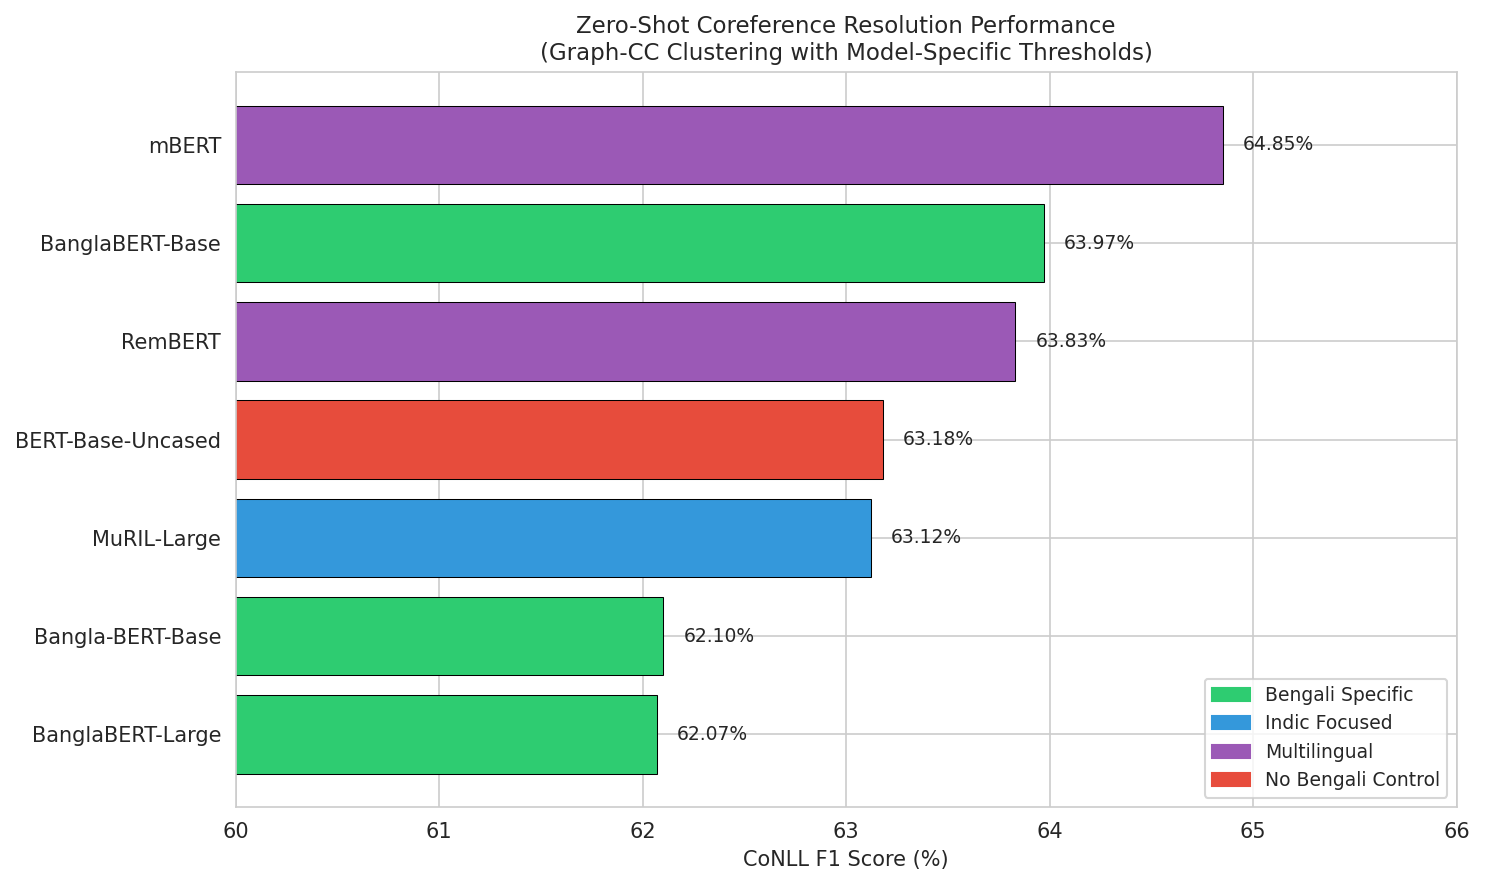

✓ Saved: model_comparison.png/pdf


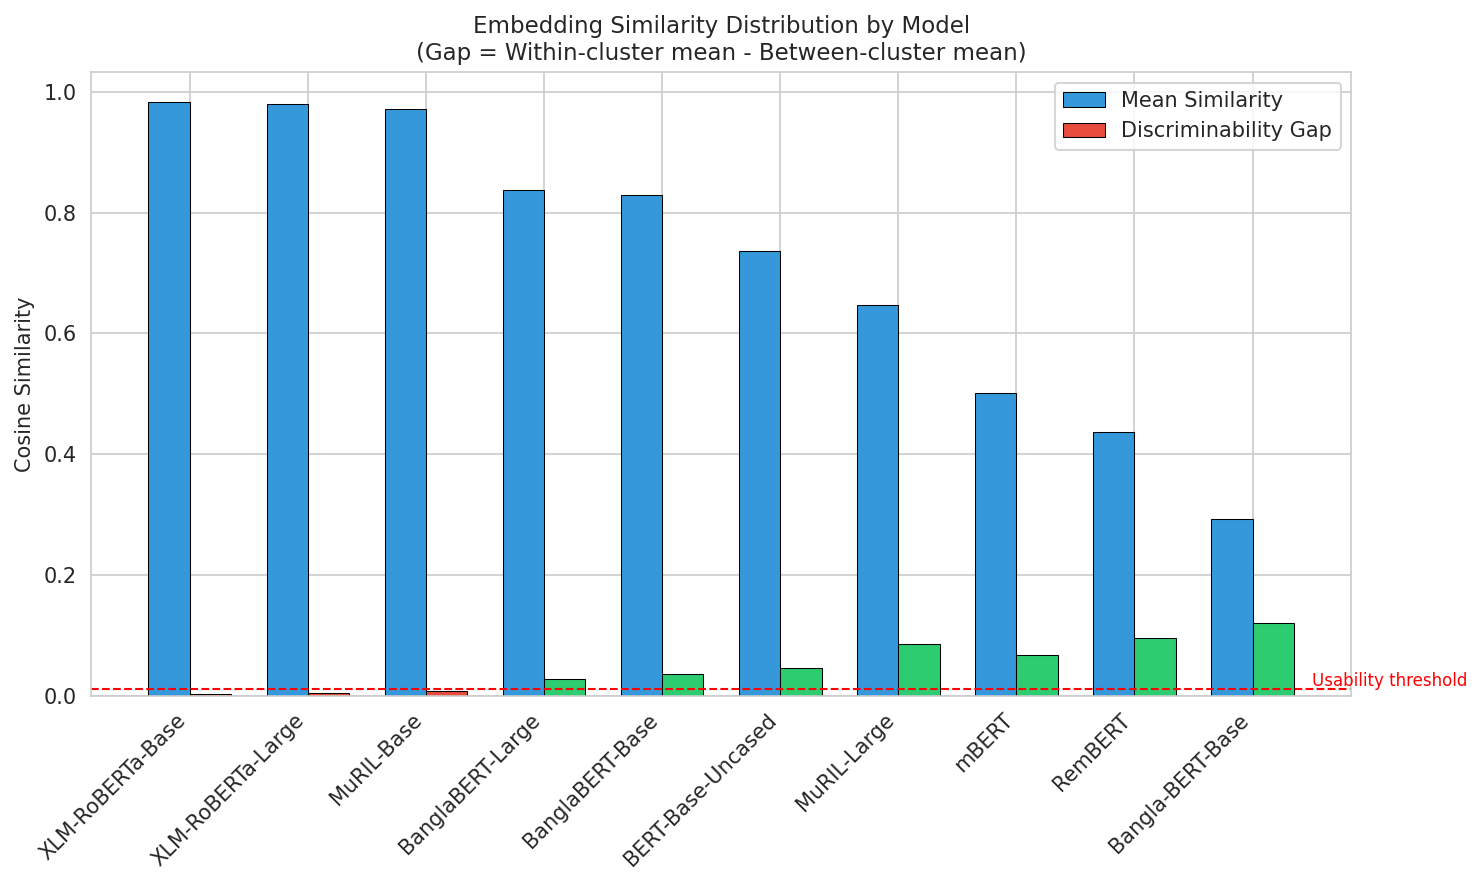

✓ Saved: similarity_distribution.png/pdf


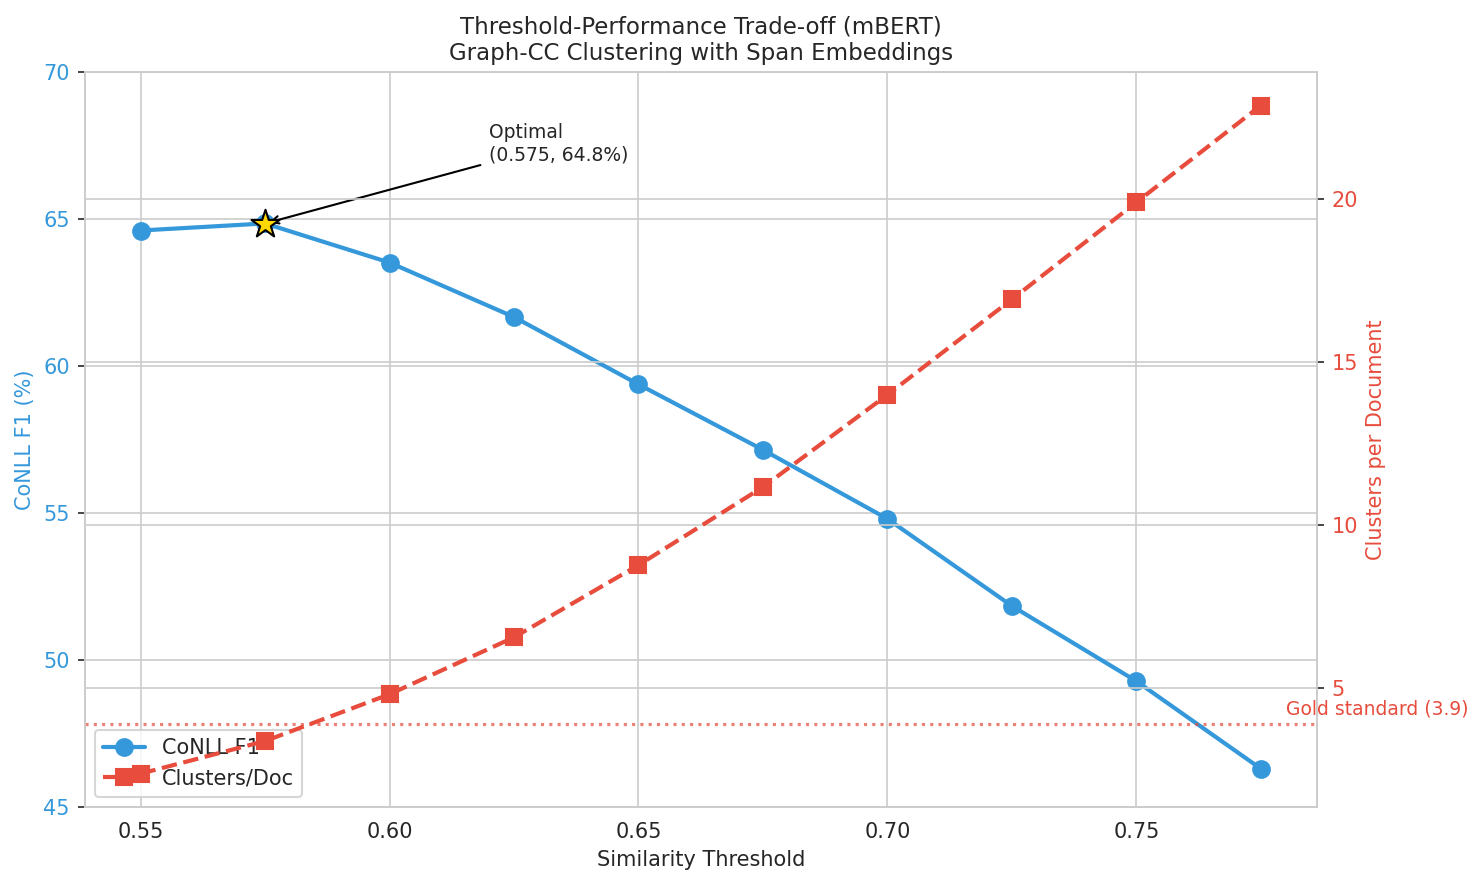

✓ Saved: threshold_tradeoff.png/pdf


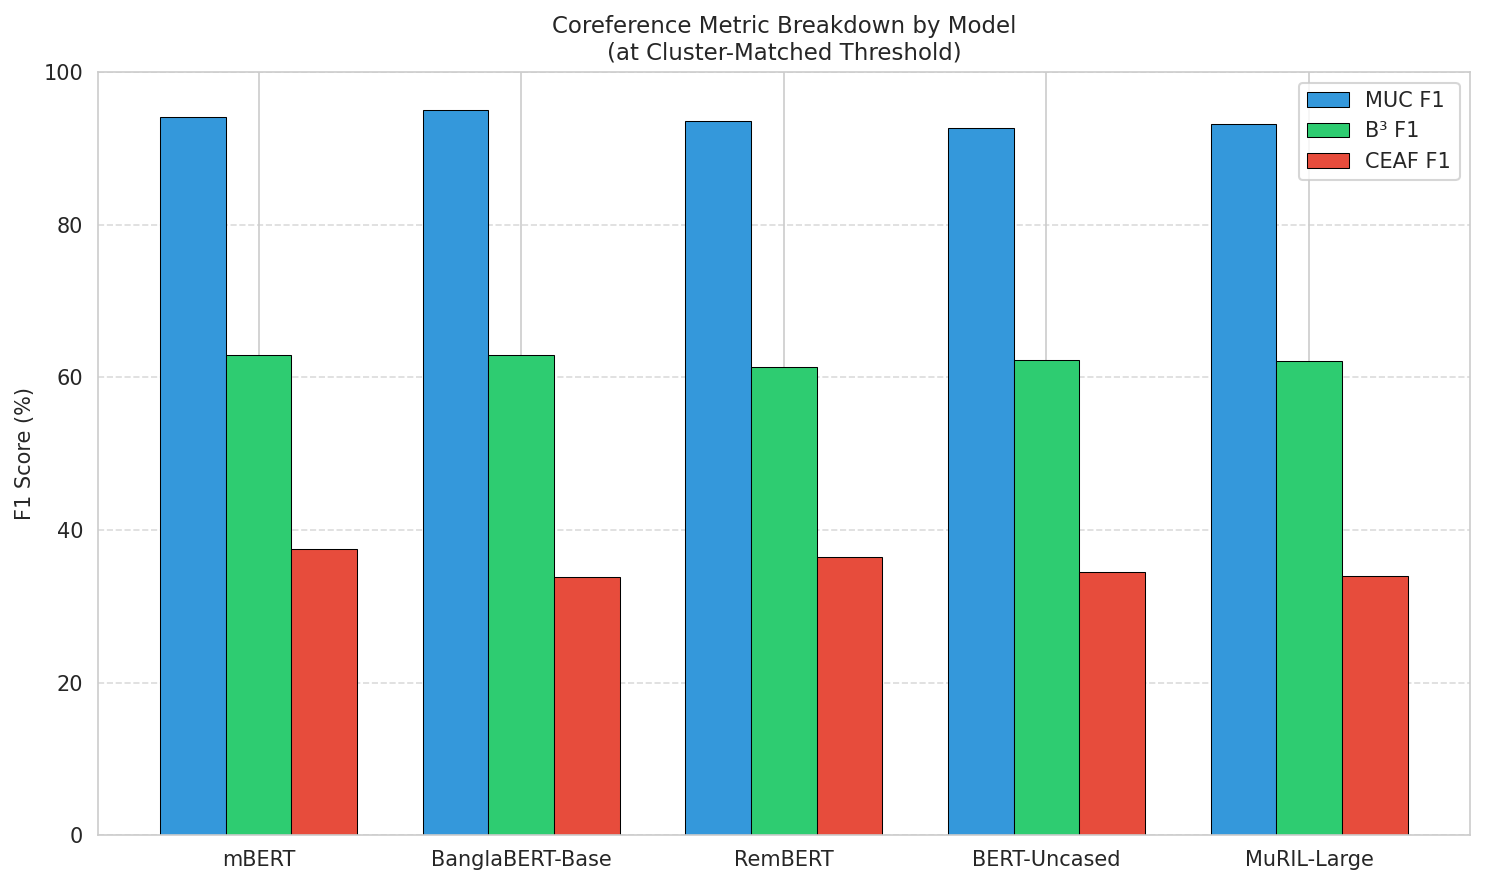

✓ Saved: metric_breakdown.png/pdf

All figures saved to: /teamspace/studios/this_studio/clustering_comparison_results/figures


In [24]:
"""
Create publication-quality visualizations for thesis.
"""

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Set style for academic figures
plt.rcParams['figure.dpi'] = 150
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 10

fig_dir = OUTPUT_DIR / "figures"
fig_dir.mkdir(exist_ok=True)

# =============================================================================
# FIGURE 1: Model Performance Comparison (Bar Chart)
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 6))

# Data for usable models
models = ['mBERT', 'BanglaBERT-Base', 'RemBERT', 'BERT-Base-Uncased', 
          'MuRIL-Large', 'Bangla-BERT-Base', 'BanglaBERT-Large']
conll_scores = [64.85, 63.97, 63.83, 63.18, 63.12, 62.10, 62.07]
categories = ['multilingual', 'bengali-specific', 'multilingual', 'no-bengali-control',
              'indic-focused', 'bengali-specific', 'bengali-specific']

# Color map by category
color_map = {
    'bengali-specific': '#2ecc71',
    'indic-focused': '#3498db', 
    'multilingual': '#9b59b6',
    'no-bengali-control': '#e74c3c'
}
colors = [color_map[cat] for cat in categories]

bars = ax.barh(range(len(models)), conll_scores, color=colors, edgecolor='black', linewidth=0.5)
ax.set_yticks(range(len(models)))
ax.set_yticklabels(models)
ax.set_xlabel('CoNLL F1 Score (%)')
ax.set_title('Zero-Shot Coreference Resolution Performance\n(Graph-CC Clustering with Model-Specific Thresholds)')
ax.set_xlim(60, 66)

# Add value labels
for i, (bar, score) in enumerate(zip(bars, conll_scores)):
    ax.text(score + 0.1, bar.get_y() + bar.get_height()/2, f'{score:.2f}%', 
            va='center', ha='left', fontsize=9)

# Legend
legend_patches = [mpatches.Patch(color=color_map[cat], label=cat.replace('-', ' ').title()) 
                  for cat in ['bengali-specific', 'indic-focused', 'multilingual', 'no-bengali-control']]
ax.legend(handles=legend_patches, loc='lower right', fontsize=9)

ax.invert_yaxis()
plt.tight_layout()
plt.savefig(fig_dir / 'model_comparison.png', bbox_inches='tight')
plt.savefig(fig_dir / 'model_comparison.pdf', bbox_inches='tight')
plt.show()

print(f"✓ Saved: model_comparison.png/pdf")

# =============================================================================
# FIGURE 2: Similarity Distribution Analysis
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 6))

# Data from similarity analysis
sim_data = [
    ('XLM-RoBERTa-Base', 0.984, 0.003, 'collapsed'),
    ('XLM-RoBERTa-Large', 0.981, 0.004, 'collapsed'),
    ('MuRIL-Base', 0.972, 0.007, 'collapsed'),
    ('BanglaBERT-Large', 0.837, 0.027, 'usable'),
    ('BanglaBERT-Base', 0.829, 0.035, 'usable'),
    ('BERT-Base-Uncased', 0.737, 0.046, 'usable'),
    ('MuRIL-Large', 0.648, 0.086, 'usable'),
    ('mBERT', 0.502, 0.067, 'usable'),
    ('RemBERT', 0.437, 0.096, 'usable'),
    ('Bangla-BERT-Base', 0.293, 0.120, 'usable'),
]

models_sim = [d[0] for d in sim_data]
mean_sims = [d[1] for d in sim_data]
gaps = [d[2] for d in sim_data]
status = [d[3] for d in sim_data]

colors_sim = ['#e74c3c' if s == 'collapsed' else '#2ecc71' for s in status]

x = np.arange(len(models_sim))
width = 0.35

bars1 = ax.bar(x - width/2, mean_sims, width, label='Mean Similarity', color='#3498db', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x + width/2, gaps, width, label='Discriminability Gap', color=colors_sim, edgecolor='black', linewidth=0.5)

ax.set_ylabel('Cosine Similarity')
ax.set_title('Embedding Similarity Distribution by Model\n(Gap = Within-cluster mean - Between-cluster mean)')
ax.set_xticks(x)
ax.set_xticklabels(models_sim, rotation=45, ha='right')
ax.legend(loc='upper right')

# Add threshold line
ax.axhline(y=0.01, color='red', linestyle='--', linewidth=1, label='Usability threshold (gap=0.01)')
ax.text(len(models_sim)-0.5, 0.015, 'Usability threshold', fontsize=8, color='red')

plt.tight_layout()
plt.savefig(fig_dir / 'similarity_distribution.png', bbox_inches='tight')
plt.savefig(fig_dir / 'similarity_distribution.pdf', bbox_inches='tight')
plt.show()

print(f"✓ Saved: similarity_distribution.png/pdf")

# =============================================================================
# FIGURE 3: Threshold vs Clusters Trade-off (for one model)
# =============================================================================

fig, ax1 = plt.subplots(figsize=(10, 6))

# Use mBERT data as example
mbert_data = optimal_results['mBERT']['all_results']
thresholds_mbert = [d['threshold'] for d in mbert_data]
clusters_mbert = [d['n_clusters'] for d in mbert_data]
conll_mbert = [d['CoNLL_F1'] for d in mbert_data]

ax1.set_xlabel('Similarity Threshold')
ax1.set_ylabel('CoNLL F1 (%)', color='#3498db')
line1 = ax1.plot(thresholds_mbert, conll_mbert, 'o-', color='#3498db', linewidth=2, markersize=8, label='CoNLL F1')
ax1.tick_params(axis='y', labelcolor='#3498db')
ax1.set_ylim(45, 70)

ax2 = ax1.twinx()
ax2.set_ylabel('Clusters per Document', color='#e74c3c')
line2 = ax2.plot(thresholds_mbert, clusters_mbert, 's--', color='#e74c3c', linewidth=2, markersize=8, label='Clusters/Doc')
ax2.tick_params(axis='y', labelcolor='#e74c3c')
ax2.axhline(y=3.9, color='#e74c3c', linestyle=':', linewidth=1.5, alpha=0.7)
ax2.text(0.78, 4.2, 'Gold standard (3.9)', fontsize=9, color='#e74c3c')

# Highlight optimal point
optimal_thresh = 0.575
optimal_conll = 64.85
optimal_clusters = 3.4
ax1.scatter([optimal_thresh], [optimal_conll], s=200, c='gold', edgecolor='black', zorder=5, marker='*')
ax1.annotate(f'Optimal\n({optimal_thresh}, {optimal_conll:.1f}%)', 
             xy=(optimal_thresh, optimal_conll), xytext=(0.62, 67),
             arrowprops=dict(arrowstyle='->', color='black'), fontsize=9)

ax1.set_title('Threshold-Performance Trade-off (mBERT)\nGraph-CC Clustering with Span Embeddings')

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower left')

plt.tight_layout()
plt.savefig(fig_dir / 'threshold_tradeoff.png', bbox_inches='tight')
plt.savefig(fig_dir / 'threshold_tradeoff.pdf', bbox_inches='tight')
plt.show()

print(f"✓ Saved: threshold_tradeoff.png/pdf")

# =============================================================================
# FIGURE 4: Metric Breakdown (Stacked/Grouped Bar)
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 6))

models_metrics = ['mBERT', 'BanglaBERT-Base', 'RemBERT', 'BERT-Uncased', 'MuRIL-Large']
muc_scores = [94.1, 95.0, 93.6, 92.7, 93.2]
b3_scores = [63.0, 63.0, 61.4, 62.3, 62.1]
ceaf_scores = [37.5, 33.9, 36.5, 34.5, 34.0]

x = np.arange(len(models_metrics))
width = 0.25

bars1 = ax.bar(x - width, muc_scores, width, label='MUC F1', color='#3498db', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x, b3_scores, width, label='B³ F1', color='#2ecc71', edgecolor='black', linewidth=0.5)
bars3 = ax.bar(x + width, ceaf_scores, width, label='CEAF F1', color='#e74c3c', edgecolor='black', linewidth=0.5)

ax.set_ylabel('F1 Score (%)')
ax.set_title('Coreference Metric Breakdown by Model\n(at Cluster-Matched Threshold)')
ax.set_xticks(x)
ax.set_xticklabels(models_metrics)
ax.legend(loc='upper right')
ax.set_ylim(0, 100)

# Add gridlines
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(fig_dir / 'metric_breakdown.png', bbox_inches='tight')
plt.savefig(fig_dir / 'metric_breakdown.pdf', bbox_inches='tight')
plt.show()

print(f"✓ Saved: metric_breakdown.png/pdf")

print("\n" + "=" * 80)
print(f"All figures saved to: {fig_dir}")
print("=" * 80)

In [25]:
"""
Final Model Selection and Optimal Settings for Fine-Tuning Experiments
"""

print("=" * 80)
print("FINAL MODEL SELECTION FOR FINE-TUNING")
print("=" * 80)

# Optimal settings from experiments
optimal_settings = {
    'mBERT': {
        'hf_model_id': 'google-bert/bert-base-multilingual-cased',
        'category': 'multilingual',
        'size': 'base',
        'zero_shot_conll_f1': 64.85,
        'optimal_threshold': 0.575,
        'clusters_per_doc': 3.4,
        'embedding_strategy': 'span',
        'clustering_algorithm': 'graph_cc',
        'similarity_gap': 0.067,
        'status': 'usable',
    },
    'BanglaBERT-Base': {
        'hf_model_id': 'csebuetnlp/banglabert',
        'category': 'bengali-specific',
        'size': 'base',
        'zero_shot_conll_f1': 63.97,
        'optimal_threshold': 0.860,
        'clusters_per_doc': 3.5,
        'embedding_strategy': 'span',
        'clustering_algorithm': 'graph_cc',
        'similarity_gap': 0.035,
        'status': 'usable',
    },
    'RemBERT': {
        'hf_model_id': 'google/rembert',
        'category': 'low-resource-specialist',
        'size': 'large',
        'zero_shot_conll_f1': 63.83,
        'optimal_threshold': 0.525,
        'clusters_per_doc': 3.5,
        'embedding_strategy': 'span',
        'clustering_algorithm': 'graph_cc',
        'similarity_gap': 0.096,
        'status': 'usable',
    },
    'BERT-Base-Uncased': {
        'hf_model_id': 'google-bert/bert-base-uncased',
        'category': 'no-bengali-control',
        'size': 'base',
        'zero_shot_conll_f1': 63.18,
        'optimal_threshold': 0.800,
        'clusters_per_doc': 4.3,
        'embedding_strategy': 'span',
        'clustering_algorithm': 'graph_cc',
        'similarity_gap': 0.046,
        'status': 'usable',
    },
    'MuRIL-Large': {
        'hf_model_id': 'google/muril-large-cased',
        'category': 'indic-focused',
        'size': 'large',
        'zero_shot_conll_f1': 63.12,
        'optimal_threshold': 0.700,
        'clusters_per_doc': 4.8,
        'embedding_strategy': 'span',
        'clustering_algorithm': 'graph_cc',
        'similarity_gap': 0.086,
        'status': 'usable',
    },
    'BanglaBERT-Large': {
        'hf_model_id': 'csebuetnlp/banglabert_large',
        'category': 'bengali-specific',
        'size': 'large',
        'zero_shot_conll_f1': 62.07,
        'optimal_threshold': 0.910,
        'clusters_per_doc': 4.4,
        'embedding_strategy': 'span',
        'clustering_algorithm': 'graph_cc',
        'similarity_gap': 0.027,
        'status': 'usable',
    },
    'Bangla-BERT-Base': {
        'hf_model_id': 'sagorsarker/bangla-bert-base',
        'category': 'bengali-specific',
        'size': 'base',
        'zero_shot_conll_f1': 62.10,
        'optimal_threshold': 0.400,
        'clusters_per_doc': 4.7,
        'embedding_strategy': 'span',
        'clustering_algorithm': 'graph_cc',
        'similarity_gap': 0.120,
        'status': 'usable',
    },
    # Collapsed models - included for reference
    'XLM-RoBERTa-Large': {
        'hf_model_id': 'xlm-roberta-large',
        'category': 'multilingual',
        'size': 'large',
        'zero_shot_conll_f1': None,
        'optimal_threshold': None,
        'clusters_per_doc': None,
        'embedding_strategy': 'span',
        'clustering_algorithm': None,
        'similarity_gap': 0.004,
        'status': 'collapsed',
    },
    'XLM-RoBERTa-Base': {
        'hf_model_id': 'xlm-roberta-base',
        'category': 'multilingual',
        'size': 'base',
        'zero_shot_conll_f1': None,
        'optimal_threshold': None,
        'clusters_per_doc': None,
        'embedding_strategy': 'span',
        'clustering_algorithm': None,
        'similarity_gap': 0.003,
        'status': 'collapsed',
    },
    'MuRIL-Base': {
        'hf_model_id': 'google/muril-base-cased',
        'category': 'indic-focused',
        'size': 'base',
        'zero_shot_conll_f1': None,
        'optimal_threshold': None,
        'clusters_per_doc': None,
        'embedding_strategy': 'span',
        'clustering_algorithm': None,
        'similarity_gap': 0.007,
        'status': 'collapsed',
    },
}

# Display usable models ranked by performance
print("\n" + "=" * 80)
print("USABLE MODELS - RANKED BY ZERO-SHOT PERFORMANCE")
print("=" * 80)
print(f"{'Rank':<6} {'Model':<22} {'Category':<22} {'CoNLL F1':>10} {'Threshold':>10} {'Clusters':>10}")
print("-" * 90)

usable = [(k, v) for k, v in optimal_settings.items() if v['status'] == 'usable']
usable_sorted = sorted(usable, key=lambda x: x[1]['zero_shot_conll_f1'], reverse=True)

for rank, (name, settings) in enumerate(usable_sorted, 1):
    print(f"{rank:<6} {name:<22} {settings['category']:<22} "
          f"{settings['zero_shot_conll_f1']:>9.2f}% {settings['optimal_threshold']:>10.3f} "
          f"{settings['clusters_per_doc']:>10.1f}")

print("-" * 90)
print(f"{'Gold Standard':<52} {'':<20} {'3.9':>10}")

# Display collapsed models
print("\n" + "=" * 80)
print("COLLAPSED MODELS (Unusable for zero-shot threshold-based clustering)")
print("=" * 80)
print(f"{'Model':<22} {'Category':<22} {'Similarity Gap':>15} {'Reason':<30}")
print("-" * 90)

collapsed = [(k, v) for k, v in optimal_settings.items() if v['status'] == 'collapsed']
for name, settings in collapsed:
    print(f"{name:<22} {settings['category']:<22} {settings['similarity_gap']:>15.4f} "
          f"{'All pairs >0.94 similarity':<30}")

# Save to JSON
settings_file = OUTPUT_DIR / "model_optimal_settings.json"
with open(settings_file, 'w') as f:
    json.dump(optimal_settings, f, indent=2)

print(f"\n✓ Optimal settings saved to: {settings_file}")
print("=" * 80)

FINAL MODEL SELECTION FOR FINE-TUNING

USABLE MODELS - RANKED BY ZERO-SHOT PERFORMANCE
Rank   Model                  Category                 CoNLL F1  Threshold   Clusters
------------------------------------------------------------------------------------------
1      mBERT                  multilingual               64.85%      0.575        3.4
2      BanglaBERT-Base        bengali-specific           63.97%      0.860        3.5
3      RemBERT                low-resource-specialist     63.83%      0.525        3.5
4      BERT-Base-Uncased      no-bengali-control         63.18%      0.800        4.3
5      MuRIL-Large            indic-focused              63.12%      0.700        4.8
6      Bangla-BERT-Base       bengali-specific           62.10%      0.400        4.7
7      BanglaBERT-Large       bengali-specific           62.07%      0.910        4.4
------------------------------------------------------------------------------------------
Gold Standard                             

In [26]:
"""
FINAL MODEL SELECTION FOR FINE-TUNING EXPERIMENTS
Save all optimal settings and configurations.
"""

print("=" * 80)
print("FINAL MODEL SELECTION FOR FINE-TUNING EXPERIMENTS")
print("=" * 80)

# =============================================================================
# OPTIMAL CLUSTERING CONFIGURATION (Used for all models)
# =============================================================================

OPTIMAL_CLUSTERING_CONFIG = {
    'embedding_strategy': 'span',
    'embedding_description': 'Concatenation of [start_token, end_token, mean_tokens] embeddings',
    'embedding_dimension': '3 × hidden_dim (e.g., 3×768=2304 for base models)',
    'clustering_algorithm': 'graph_cc',
    'clustering_description': 'Graph-based Connected Components',
    'clustering_details': {
        'method': 'Build similarity graph where nodes=mentions, edges connect pairs with similarity >= threshold',
        'clusters': 'Connected components in the graph (transitive closure)',
        'library': 'NetworkX (nx.connected_components)',
    },
    'threshold_strategy': 'model_specific',
    'threshold_description': 'Each model requires different threshold based on its embedding similarity distribution',
}

# =============================================================================
# SELECTED MODELS (5 Models)
# =============================================================================

SELECTED_MODELS_FOR_FINETUNING = {
    'mBERT': {
        'hf_model_id': 'google-bert/bert-base-multilingual-cased',
        'category': 'multilingual',
        'size': 'base',
        'parameters': '110M',
        'hidden_dim': 768,
        'zero_shot_conll_f1': 64.85,
        'optimal_threshold': 0.575,
        'clusters_per_doc': 3.4,
        'similarity_gap': 0.067,
        'research_question': 'Best zero-shot performer - baseline for fine-tuning comparison',
        'selection_reason': 'Highest zero-shot F1, good embedding discriminability',
    },
    'BanglaBERT-Base': {
        'hf_model_id': 'csebuetnlp/banglabert',
        'category': 'bengali-specific',
        'size': 'base',
        'parameters': '110M',
        'hidden_dim': 768,
        'zero_shot_conll_f1': 63.97,
        'optimal_threshold': 0.860,
        'clusters_per_doc': 3.5,
        'similarity_gap': 0.035,
        'research_question': 'Does Bengali-specific pre-training provide advantage after fine-tuning?',
        'selection_reason': 'Best Bengali-specific model, outperforms BanglaBERT-Large',
    },
    'RemBERT': {
        'hf_model_id': 'google/rembert',
        'category': 'low-resource-specialist',
        'size': 'large',
        'parameters': '559M',
        'hidden_dim': 1152,
        'zero_shot_conll_f1': 63.83,
        'optimal_threshold': 0.525,
        'clusters_per_doc': 3.5,
        'similarity_gap': 0.096,
        'research_question': 'Does low-resource-optimized architecture benefit Bengali coreference?',
        'selection_reason': 'Designed for low-resource languages, high embedding discriminability',
    },
    'MuRIL-Large': {
        'hf_model_id': 'google/muril-large-cased',
        'category': 'indic-focused',
        'size': 'large',
        'parameters': '237M',
        'hidden_dim': 1024,
        'zero_shot_conll_f1': 63.12,
        'optimal_threshold': 0.700,
        'clusters_per_doc': 4.8,
        'similarity_gap': 0.086,
        'research_question': 'Can Hindi/Indic pre-training transfer to Bengali coreference?',
        'selection_reason': 'Only usable Indic-focused model (MuRIL-Base has collapsed embeddings)',
    },
    'BERT-Base-Uncased': {
        'hf_model_id': 'google-bert/bert-base-uncased',
        'category': 'no-bengali-control',
        'size': 'base',
        'parameters': '110M',
        'hidden_dim': 768,
        'zero_shot_conll_f1': 63.18,
        'optimal_threshold': 0.800,
        'clusters_per_doc': 4.3,
        'similarity_gap': 0.046,
        'research_question': 'Is Bengali pre-training necessary, or can task-specific fine-tuning compensate?',
        'selection_reason': 'Control model - no Bengali knowledge, tests fine-tuning potential',
    },
}

# =============================================================================
# DISPLAY CONFIGURATION
# =============================================================================

print("\n" + "=" * 80)
print("CLUSTERING CONFIGURATION")
print("=" * 80)
print(f"""
┌─────────────────────────────────────────────────────────────────────────────────┐
│  EMBEDDING STRATEGY                                                             │
├─────────────────────────────────────────────────────────────────────────────────┤
│  Type: Span Embeddings                                                          │
│  Formula: [start_token || end_token || mean_tokens]                             │
│  Dimension: 3 × hidden_dim (e.g., 2304 for 768-dim models)                      │
│                                                                                 │
│  Why: Preserves mention boundary information better than mean-pooling           │
├─────────────────────────────────────────────────────────────────────────────────┤
│  CLUSTERING ALGORITHM                                                           │
├─────────────────────────────────────────────────────────────────────────────────┤
│  Type: Graph-based Connected Components (graph_cc)                              │
│                                                                                 │
│  Steps:                                                                         │
│    1. Compute pairwise cosine similarity matrix for all mentions                │
│    2. Build undirected graph: nodes = mentions                                  │
│    3. Add edge between mentions i,j if similarity(i,j) >= threshold             │
│    4. Find connected components using NetworkX                                  │
│    5. Each connected component = one coreference cluster                        │
│                                                                                 │
│  Property: Transitive closure (if A~B and B~C, then A,B,C in same cluster)     │
│                                                                                 │
│  Why: Outperformed greedy and hierarchical methods in experiments               │
├─────────────────────────────────────────────────────────────────────────────────┤
│  THRESHOLD STRATEGY                                                             │
├─────────────────────────────────────────────────────────────────────────────────┤
│  Type: Model-Specific Adaptive Thresholds                                       │
│                                                                                 │
│  Each model has different embedding similarity distributions, requiring         │
│  different thresholds to achieve proper cluster separation (~3.9 clusters/doc)  │
│                                                                                 │
│  Thresholds determined by: Similarity distribution analysis + grid search       │
│  Validation criterion: clusters/doc ≈ gold standard (3.9)                       │
│                                                                                 │
└─────────────────────────────────────────────────────────────────────────────────┘
""")

print("=" * 80)
print("SELECTED MODELS (5)")
print("=" * 80)
print(f"""
┌─────────────────────────────────────────────────────────────────────────────────┐
│  Rank │ Model              │ Category            │ F1     │ Threshold │ Params  │
├───────┼────────────────────┼─────────────────────┼────────┼───────────┼─────────┤
│  1    │ mBERT              │ multilingual        │ 64.85% │   0.575   │ 110M    │
│  2    │ BanglaBERT-Base    │ bengali-specific    │ 63.97% │   0.860   │ 110M    │
│  3    │ RemBERT            │ low-resource        │ 63.83% │   0.525   │ 559M    │
│  4    │ BERT-Base-Uncased  │ no-bengali-control  │ 63.18% │   0.800   │ 110M    │
│  5    │ MuRIL-Large        │ indic-focused       │ 63.12% │   0.700   │ 237M    │
└───────┴────────────────────┴─────────────────────┴────────┴───────────┴─────────┘

Gold Standard: 3.9 clusters/document
""")

print("=" * 80)
print("RESEARCH QUESTIONS FOR FINE-TUNING")
print("=" * 80)
for model_name, config in SELECTED_MODELS_FOR_FINETUNING.items():
    print(f"\n  {model_name}:")
    print(f"    → {config['research_question']}")

# =============================================================================
# SAVE COMPLETE CONFIGURATION
# =============================================================================

final_config = {
    'experiment_name': 'Zero-Shot Clustering Algorithm Comparison for Bengali Coreference',
    'dataset': {
        'name': 'BenCoref',
        'documents': 122,
        'mentions': 5488,
        'clusters': 470,
        'avg_clusters_per_doc': 3.9,
        'domains': ['biography', 'descriptive', 'novel', 'story'],
    },
    'clustering_config': OPTIMAL_CLUSTERING_CONFIG,
    'selected_models': SELECTED_MODELS_FOR_FINETUNING,
    'excluded_models': {
        'collapsed_embeddings': ['XLM-RoBERTa-Large', 'XLM-RoBERTa-Base', 'MuRIL-Base'],
        'redundant': ['BanglaBERT-Large', 'Bangla-BERT-Base'],
        'reason_collapsed': 'Similarity gap < 0.01, all pairs have similarity > 0.94',
        'reason_redundant': 'Category already represented by better-performing model',
    },
    'key_findings': [
        'Graph-based Connected Components outperforms greedy and hierarchical clustering',
        'Span embeddings (start+end+mean) provide better discrimination than mean-pooling',
        'Each model requires model-specific threshold based on similarity distribution',
        'XLM-RoBERTa models have collapsed embeddings unusable for zero-shot clustering',
        'mBERT achieves best zero-shot performance despite being a base model',
        'Model size does not guarantee better performance (BanglaBERT-Base > BanglaBERT-Large)',
    ],
    'metadata': {
        'date': datetime.now().isoformat(),
        'author': 'Zenith',
        'purpose': 'Model selection for fine-tuning experiments in Bengali coreference resolution',
    }
}

# Save to JSON
final_config_file = OUTPUT_DIR / "final_model_selection.json"
with open(final_config_file, 'w') as f:
    json.dump(final_config, f, indent=2)

print("\n" + "=" * 80)
print("FILES SAVED")
print("=" * 80)
print(f"  ✓ {final_config_file}")
print(f"  ✓ {OUTPUT_DIR / 'model_optimal_settings.json'}")
print(f"  ✓ {OUTPUT_DIR / 'optimal_threshold_search.json'}")
print(f"  ✓ {OUTPUT_DIR / 'similarity_analysis.csv'}")

print("\n" + "=" * 80)
print("NEXT STEPS: FINE-TUNING EXPERIMENTS")
print("=" * 80)
print("""
For each of the 5 selected models:

1. LOAD with optimal settings from this experiment
2. FINE-TUNE using BenCoref training data
3. EVALUATE using same clustering configuration:
   - Embedding: Span (start + end + mean)
   - Algorithm: Graph-based Connected Components
   - Threshold: Start with optimal threshold, may need re-tuning after fine-tuning
4. COMPARE zero-shot vs fine-tuned performance
5. ANALYZE which model benefits most from fine-tuning
""")
print("=" * 80)
print("EXPERIMENT COMPLETE")
print("=" * 80)

FINAL MODEL SELECTION FOR FINE-TUNING EXPERIMENTS

CLUSTERING CONFIGURATION

┌─────────────────────────────────────────────────────────────────────────────────┐
│  EMBEDDING STRATEGY                                                             │
├─────────────────────────────────────────────────────────────────────────────────┤
│  Type: Span Embeddings                                                          │
│  Formula: [start_token || end_token || mean_tokens]                             │
│  Dimension: 3 × hidden_dim (e.g., 2304 for 768-dim models)                      │
│                                                                                 │
│  Why: Preserves mention boundary information better than mean-pooling           │
├─────────────────────────────────────────────────────────────────────────────────┤
│  CLUSTERING ALGORITHM                                                           │
├─────────────────────────────────────────────────────────────────────────────────┤